Initialized analyzer with 1609 windows of length 10
🔋 EV TIME SERIES WINDOW ANALYSIS REPORT
BASIC WINDOW STATISTICS
Total number of events across all windows: 16090
Number of windows: 1609
Sequence length per window: 10

Feature Statistics (across all windows):
----------------------------------------
duration_minutes:
  Mean: 97.36
  Std: 125.93
  Min: 13.32
  Max: 1119.74

km_driven:
  Mean: 32.20
  Std: 47.56
  Min: 1.29
  Max: 229.06

charge:
  Mean: -2.58
  Std: 14.49
  Min: -40.60
  Max: 37.89

WINDOW-LEVEL ANALYSIS
Window-level Summary Statistics:
----------------------------------------
         window_id  total_charge   net_charge  total_duration     total_km  \
count  1609.000000   1609.000000  1609.000000     1609.000000  1609.000000   
mean    804.000000    -25.758375   -25.758375      973.569558   321.993111   
std     464.622607     41.723148    41.723148      449.513477   144.878726   
min       0.000000    -99.386428   -99.386428      251.485272    38.882951   
25%     

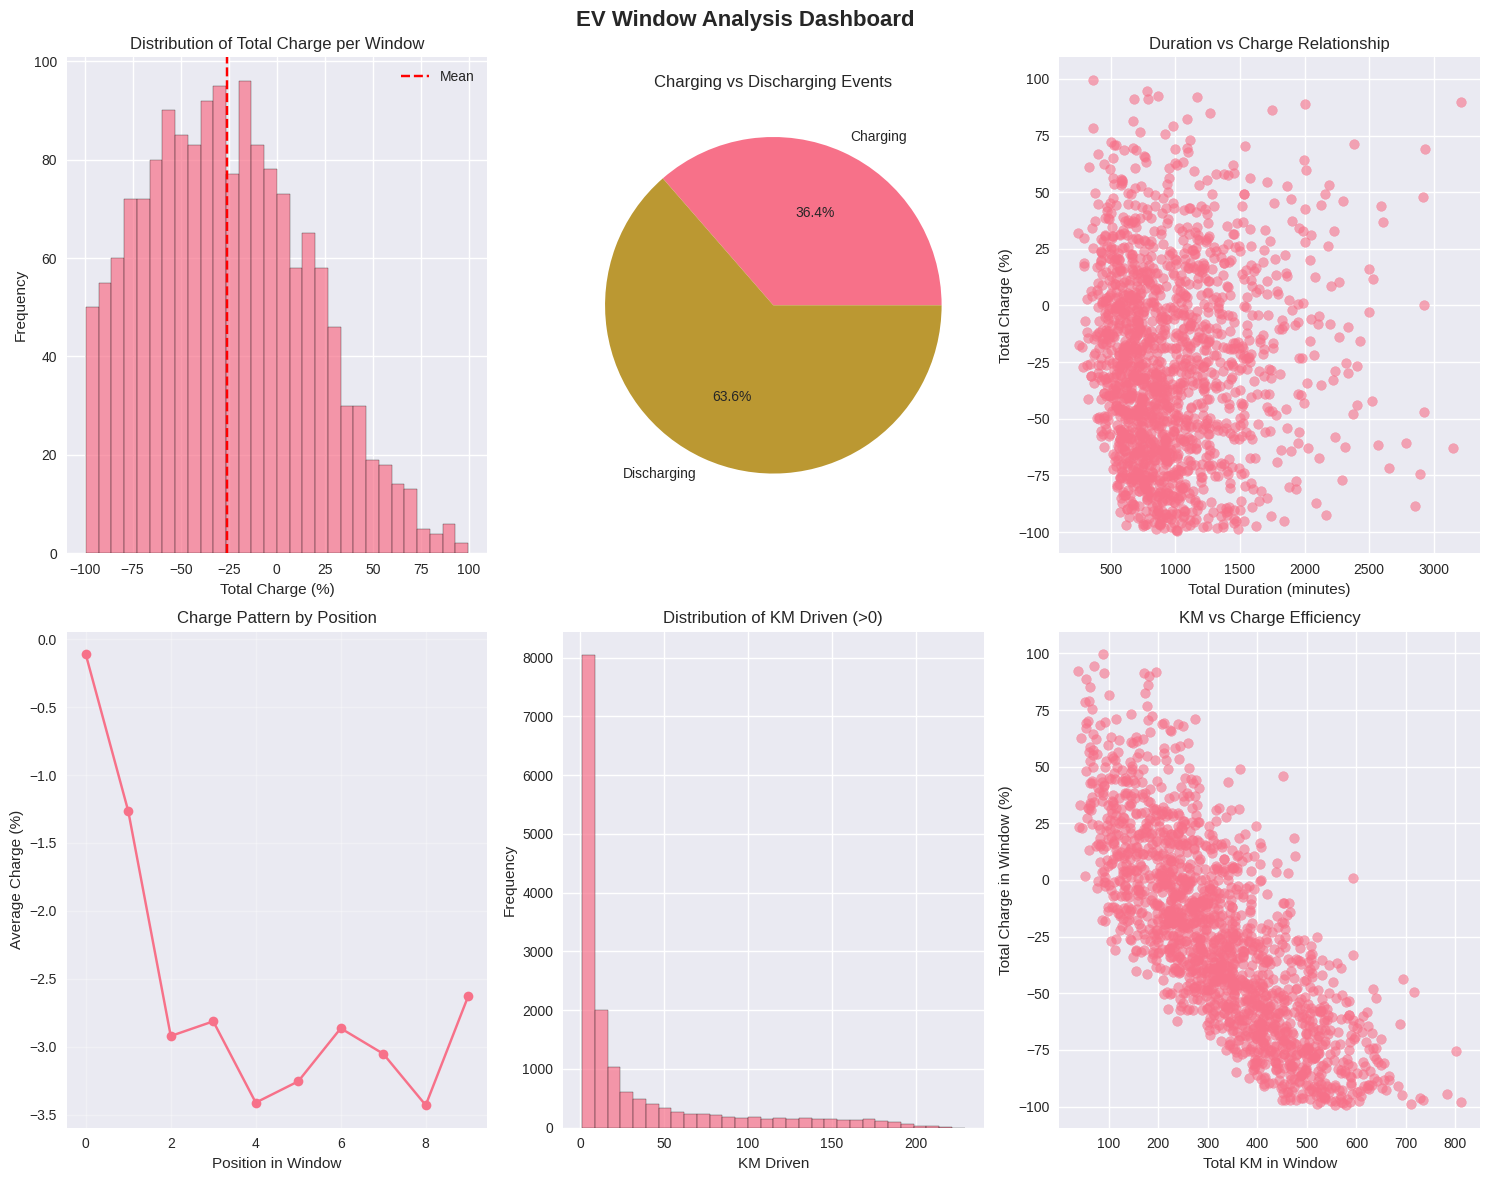

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class EVWindowAnalyzer:
    """
    Comprehensive analyzer for EV time series windows
    """
    
    def __init__(self, windows_data, seq_len):
        """
        Initialize analyzer with windowed data
        
        Parameters:
        windows_data: array-like, shape (N_windows, seq_len, n_features)
                     or list of DataFrames
        seq_len: int, sequence length of each window
        """
        self.seq_len = seq_len
        self.feature_names = ['event', 'charge_mode', 'duration_minutes', 'km_driven', 'charge']
        
        # Convert to consistent format
        if isinstance(windows_data, list):
            self.windows = windows_data
            self.n_windows = len(windows_data)
        else:
            # Assume numpy array format
            self.windows = [pd.DataFrame(windows_data[i], columns=self.feature_names) 
                           for i in range(windows_data.shape[0])]
            self.n_windows = windows_data.shape[0]
        
        print(f"Initialized analyzer with {self.n_windows} windows of length {self.seq_len}")
        
    def basic_statistics(self):
        """Generate basic statistics about all windows"""
        print("="*60)
        print("BASIC WINDOW STATISTICS")
        print("="*60)
        
        # Aggregate all windows into one dataframe for global stats
        all_data = pd.concat(self.windows, ignore_index=True)
        
        print(f"Total number of events across all windows: {len(all_data)}")
        print(f"Number of windows: {self.n_windows}")
        print(f"Sequence length per window: {self.seq_len}")
        
        # Basic feature statistics
        print("\nFeature Statistics (across all windows):")
        print("-" * 40)
        for col in ['duration_minutes', 'km_driven', 'charge']:
            if col in all_data.columns:
                print(f"{col}:")
                print(f"  Mean: {all_data[col].mean():.2f}")
                print(f"  Std: {all_data[col].std():.2f}")
                print(f"  Min: {all_data[col].min():.2f}")
                print(f"  Max: {all_data[col].max():.2f}")
                print()
        
        return all_data
    
    def window_level_analysis(self):
        """Analyze characteristics at the window level"""
        print("="*60)
        print("WINDOW-LEVEL ANALYSIS")
        print("="*60)
        
        window_stats = []
        
        for i, window in enumerate(self.windows):
            stats_dict = {
                'window_id': i,
                'total_charge': window['charge'].sum(),
                'net_charge': window['charge'].sum(),  # same as total for now
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'n_charging_events': (window['charge'] > 0).sum(),
                'n_discharging_events': (window['charge'] < 0).sum(),
                'max_single_charge': window['charge'].max(),
                'min_single_charge': window['charge'].min(),
                'charging_efficiency': window[window['charge'] > 0]['charge'].sum() if (window['charge'] > 0).any() else 0,
                'discharging_total': abs(window[window['charge'] < 0]['charge'].sum()) if (window['charge'] < 0).any() else 0,
                'avg_event_duration': window['duration_minutes'].mean(),
                'longest_event': window['duration_minutes'].max(),
                'shortest_event': window['duration_minutes'].min()
            }
            
            # Event type analysis (if categorical)
            if 'event' in window.columns:
                event_counts = window['event'].value_counts()
                for event_type in event_counts.index:
                    stats_dict[f'n_{event_type}_events'] = event_counts[event_type]
            
            # Charge mode analysis (if categorical)
            if 'charge_mode' in window.columns:
                mode_counts = window['charge_mode'].value_counts()
                stats_dict['most_common_charge_mode'] = mode_counts.index[0] if len(mode_counts) > 0 else 'N/A'
                stats_dict['n_unique_charge_modes'] = len(mode_counts)
            
            window_stats.append(stats_dict)
        
        self.window_stats_df = pd.DataFrame(window_stats)
        
        # Display summary statistics
        print("Window-level Summary Statistics:")
        print("-" * 40)
        numeric_cols = self.window_stats_df.select_dtypes(include=[np.number]).columns
        print(self.window_stats_df[numeric_cols].describe())
        
        return self.window_stats_df
    
    def charge_analysis(self):
        """Deep dive into charging patterns"""
        print("="*60)
        print("CHARGING PATTERN ANALYSIS")
        print("="*60)
        
        # Charging vs Discharging analysis
        total_charging = sum(window[window['charge'] > 0]['charge'].sum() for window in self.windows)
        total_discharging = sum(abs(window[window['charge'] < 0]['charge'].sum()) for window in self.windows)
        
        print(f"Total charging across all windows: {total_charging:.2f}%")
        print(f"Total discharging across all windows: {total_discharging:.2f}%")
        print(f"Net battery change: {total_charging - total_discharging:.2f}%")
        print(f"Charge/Discharge ratio: {total_charging/total_discharging:.2f}" if total_discharging > 0 else "Infinite (no discharging)")
        
        # Window charge distribution
        charge_dist = self.window_stats_df['total_charge']
        print(f"\nWindow Total Charge Distribution:")
        print(f"  Mean window charge: {charge_dist.mean():.2f}%")
        print(f"  Std window charge: {charge_dist.std():.2f}%")
        print(f"  Windows with net positive charge: {(charge_dist > 0).sum()}")
        print(f"  Windows with net negative charge: {(charge_dist < 0).sum()}")
        print(f"  Windows with net zero charge: {(charge_dist == 0).sum()}")
        
        return {
            'total_charging': total_charging,
            'total_discharging': total_discharging,
            'net_change': total_charging - total_discharging
        }
    
    def temporal_patterns(self):
        """Analyze temporal patterns within windows"""
        print("="*60)
        print("TEMPORAL PATTERN ANALYSIS")
        print("="*60)
        
        # Analyze position-based patterns (early vs late in window)
        position_stats = []
        
        for pos in range(self.seq_len):
            pos_data = [window.iloc[pos] for window in self.windows if len(window) > pos]
            
            if pos_data:
                pos_df = pd.DataFrame(pos_data)
                position_stats.append({
                    'position': pos,
                    'avg_charge': pos_df['charge'].mean(),
                    'avg_duration': pos_df['duration_minutes'].mean(),
                    'avg_km': pos_df['km_driven'].mean(),
                    'charge_std': pos_df['charge'].std()
                })
        
        self.position_stats = pd.DataFrame(position_stats)
        
        print("Average patterns by position in window:")
        print(self.position_stats.round(2))
        
        # Find most/least active positions
        most_charge_pos = self.position_stats.loc[self.position_stats['avg_charge'].idxmax(), 'position']
        least_charge_pos = self.position_stats.loc[self.position_stats['avg_charge'].idxmin(), 'position']
        
        print(f"\nMost charging activity at position: {most_charge_pos}")
        print(f"Least charging activity at position: {least_charge_pos}")
        
        return self.position_stats
    
    def event_analysis(self):
        """Analyze event types and patterns"""
        print("="*60)
        print("EVENT TYPE ANALYSIS")
        print("="*60)
        
        # Aggregate all events
        all_events = pd.concat(self.windows, ignore_index=True)
        
        # Event type distribution
        if 'event' in all_events.columns:
            event_dist = all_events['event'].value_counts()
            print("Event type distribution:")
            for event_type, count in event_dist.items():
                pct = (count / len(all_events)) * 100
                print(f"  {event_type}: {count} ({pct:.1f}%)")
        
        # Charge mode distribution
        if 'charge_mode' in all_events.columns:
            mode_dist = all_events['charge_mode'].value_counts()
            print(f"\nCharge mode distribution:")
            for mode, count in mode_dist.items():
                pct = (count / len(all_events)) * 100
                print(f"  {mode}: {count} ({pct:.1f}%)")
        
        # Event characteristics by type
        if 'event' in all_events.columns:
            print(f"\nEvent characteristics by type:")
            event_chars = all_events.groupby('event')[['duration_minutes', 'km_driven', 'charge']].agg(['mean', 'std', 'count'])
            print(event_chars.round(2))
        
        return all_events
    
    def visualize_patterns(self, figsize=(15, 12)):
        """Create comprehensive visualizations"""
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('EV Window Analysis Dashboard', fontsize=16, fontweight='bold')
        
        # 1. Window charge distribution
        axes[0,0].hist(self.window_stats_df['total_charge'], bins=30, alpha=0.7, edgecolor='black')
        axes[0,0].set_title('Distribution of Total Charge per Window')
        axes[0,0].set_xlabel('Total Charge (%)')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].axvline(self.window_stats_df['total_charge'].mean(), color='red', linestyle='--', label='Mean')
        axes[0,0].legend()
        
        # 2. Charging vs Discharging events
        charge_pos = self.window_stats_df['n_charging_events'].sum()
        charge_neg = self.window_stats_df['n_discharging_events'].sum()
        axes[0,1].pie([charge_pos, charge_neg], labels=['Charging', 'Discharging'], autopct='%1.1f%%')
        axes[0,1].set_title('Charging vs Discharging Events')
        
        # 3. Total duration vs total charge scatter
        axes[0,2].scatter(self.window_stats_df['total_duration'], self.window_stats_df['total_charge'], alpha=0.6)
        axes[0,2].set_xlabel('Total Duration (minutes)')
        axes[0,2].set_ylabel('Total Charge (%)')
        axes[0,2].set_title('Duration vs Charge Relationship')
        
        # 4. Temporal patterns (position-based)
        if hasattr(self, 'position_stats'):
            axes[1,0].plot(self.position_stats['position'], self.position_stats['avg_charge'], marker='o')
            axes[1,0].set_xlabel('Position in Window')
            axes[1,0].set_ylabel('Average Charge (%)')
            axes[1,0].set_title('Charge Pattern by Position')
            axes[1,0].grid(True, alpha=0.3)
        
        # 5. KM driven distribution
        all_km = pd.concat(self.windows)['km_driven']
        axes[1,1].hist(all_km[all_km > 0], bins=30, alpha=0.7, edgecolor='black')
        axes[1,1].set_xlabel('KM Driven')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title('Distribution of KM Driven (>0)')
        
        # 6. Charge efficiency scatter
        axes[1,2].scatter(self.window_stats_df['total_km'], self.window_stats_df['total_charge'], alpha=0.6)
        axes[1,2].set_xlabel('Total KM in Window')
        axes[1,2].set_ylabel('Total Charge in Window (%)')
        axes[1,2].set_title('KM vs Charge Efficiency')
        
        plt.tight_layout()
        plt.show()
    
    def data_quality_check(self):
        """Check for data quality issues"""
        print("="*60)
        print("DATA QUALITY CHECK")
        print("="*60)
        
        issues = []
        
        # Check for missing values
        for i, window in enumerate(self.windows):
            missing = window.isnull().sum()
            if missing.any():
                issues.append(f"Window {i}: Missing values - {missing.to_dict()}")
        
        # Check for impossible values
        all_data = pd.concat(self.windows, ignore_index=True)
        
        if (all_data['charge'] > 100).any():
            issues.append("Found charge values > 100%")
        if (all_data['charge'] < -100).any():
            issues.append("Found charge values < -100%")
        if (all_data['duration_minutes'] < 0).any():
            issues.append("Found negative duration values")
        if (all_data['km_driven'] < 0).any():
            issues.append("Found negative km_driven values")
        
        # Check window length consistency
        lengths = [len(w) for w in self.windows]
        if not all(l == self.seq_len for l in lengths):
            issues.append(f"Inconsistent window lengths: {set(lengths)}")
        
        if issues:
            print("ISSUES FOUND:")
            for issue in issues:
                print(f"⚠️  {issue}")
        else:
            print("✅ No data quality issues detected!")
        
        return issues
    
    def generate_report(self):
        """Generate a comprehensive analysis report"""
        print("🔋 EV TIME SERIES WINDOW ANALYSIS REPORT")
        print("="*70)
        
        # Run all analyses
        basic_data = self.basic_statistics()
        window_stats = self.window_level_analysis()
        charge_analysis = self.charge_analysis()
        temporal_patterns = self.temporal_patterns()
        event_data = self.event_analysis()
        quality_issues = self.data_quality_check()
        
        # Generate visualizations
        self.visualize_patterns()
        
        return {
            'basic_stats': basic_data,
            'window_stats': window_stats,
            'charge_summary': charge_analysis,
            'temporal_patterns': temporal_patterns,
            'event_analysis': event_data,
            'quality_issues': quality_issues
        }

#USAGE
import pandas as pd

############################
data_to_load = 'generated'##
############################



if data_to_load == 'generated':
    # Load the CSV
    df = pd.read_csv("./Generated_data/EV_generated_data.csv")
    
elif data_to_load == 'original':

    df = pd.read_csv('./datasets/EV_data.csv')
    df['charge'] = df['end_soc'] - df['soc']
    df['km_driven'] = df['end_odo'] - df['odo']
    # Convert timestamps to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')

    # Compute event duration in minutes
    df['duration_minutes'] = (df['end_time'] - df['timestamp']).dt.total_seconds() / 60
    
# Define window size
seq_len = 10   
# Split into a list of DataFrames
dfs = [df.iloc[i:i+seq_len] for i in range(0, len(df), seq_len)]

# Keep only those where sum of 'charge' is between -100 and 100
dfs = [d for d in dfs if -100 <= d['charge'].sum() <= 100]

analyzer = EVWindowAnalyzer(dfs, seq_len=seq_len)
results = analyzer.generate_report()


## Timeline reconstruction

🔋 Initializing timeline reconstructor with 115 windows
Window net charges: ['-58.5%', '10.4%', '-10.4%', '11.5%', '-27.2%', '8.5%', '-11.6%', '-62.1%', '-29.8%', '10.7%', '-10.6%', '14.4%', '12.5%', '-2.6%', '73.4%', '-5.9%', '-49.2%', '-7.3%', '-65.9%', '-8.1%', '-11.3%', '62.5%', '-5.4%', '38.3%', '16.3%', '-29.5%', '36.4%', '21.2%', '-29.5%', '21.4%', '-14.8%', '14.9%', '6.3%', '91.0%', '11.3%', '24.2%', '73.9%', '-41.4%', '40.6%', '-42.5%', '12.2%', '5.7%', '-5.7%', '30.3%', '26.0%', '-9.7%', '-29.2%', '-32.5%', '53.9%', '-40.2%', '18.7%', '-13.9%', '-29.2%', '-15.7%', '3.8%', '45.9%', '12.2%', '14.3%', '-10.0%', '-54.7%', '30.1%', '-8.0%', '-48.2%', '52.0%', '-53.3%', '-26.1%', '9.4%', '-25.1%', '36.5%', '64.8%', '-28.1%', '4.0%', '-54.5%', '-41.6%', '-31.0%', '21.4%', '-15.2%', '-44.4%', '17.8%', '32.7%', '-7.1%', '17.1%', '-12.6%', '-3.3%', '8.7%', '-47.4%', '23.8%', '-22.0%', '19.4%', '29.6%', '-4.5%', '44.5%', '-41.7%', '-64.1%', '-33.4%', '9.1%', '14.9%', '38.3%', '-20.2%', '

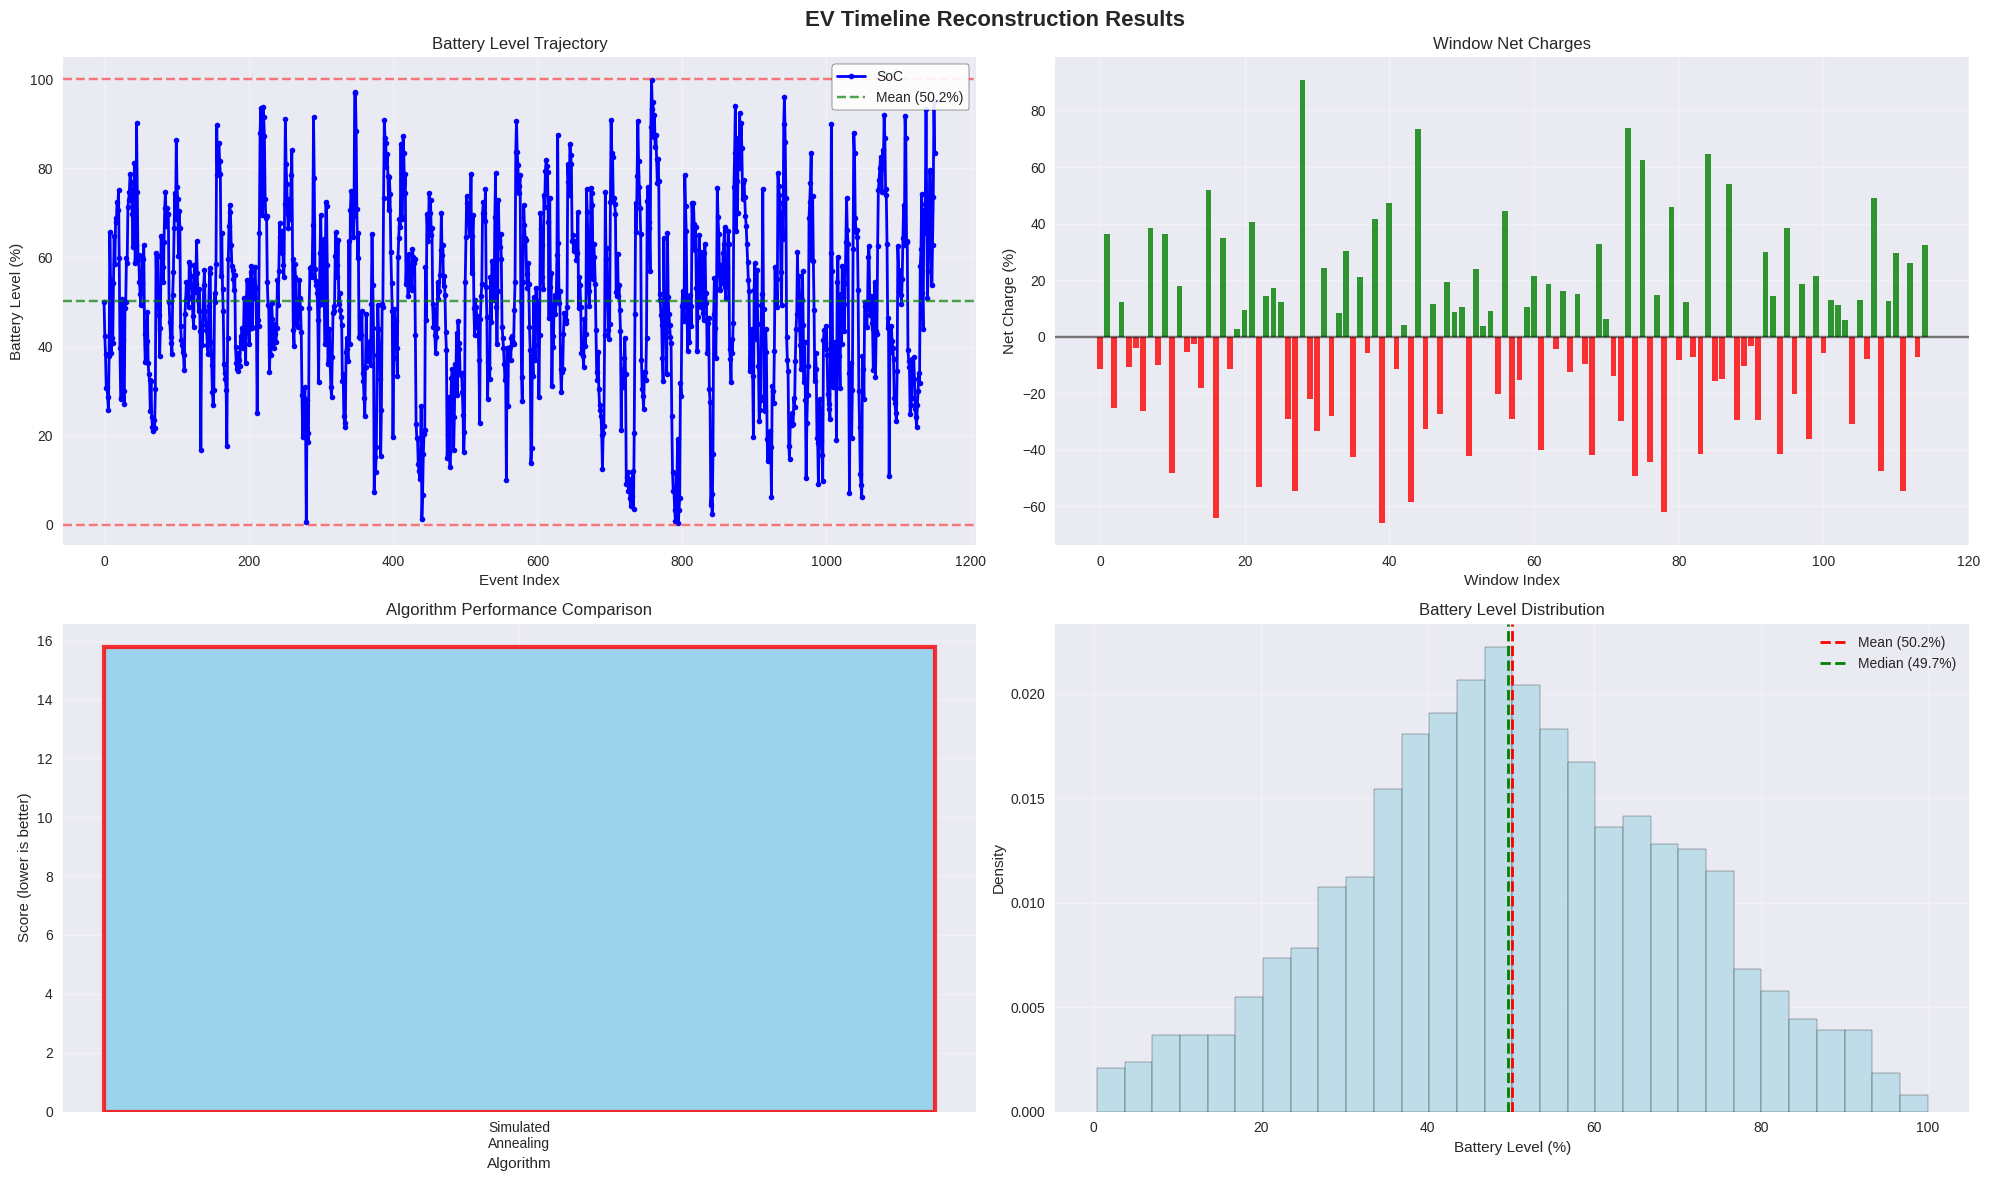


Sequence Analysis:
  Window sequence: [108, 68, 67, 104, 10, 103, 65, 97, 58, 26, 62, 78, 22, 13, 109, 63, 93, 107, 6, 114, 66, 38, 64, 11, 81, 56, 46, 72, 33, 87, 94, 35, 70, 5, 43, 39, 27, 42, 99, 18, 102, 20, 71, 0, 14, 47, 3, 4, 88, 84, 1, 105, 86, 54, 95, 112, 91, 52, 76, 9, 29, 49, 50, 90, 24, 82, 31, 45, 92, 79, 32, 51, 8, 36, 16, 21, 77, 96, 7, 55, 19, 40, 17, 73, 69, 53, 30, 48, 28, 2, 83, 25, 60, 57, 37, 23, 98, 101, 111, 75, 15, 110, 34, 41, 74, 100, 61, 106, 85, 12, 89, 59, 44, 80, 113]
  Sequence length: 115
  Battery stability (low std is better): 19.66%
  Time in safe zone (20-80%): 86.4%
  Charging windows: 58, Discharging windows: 57
  Total net change: 33.4%


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import random
from typing import List, Tuple, Dict, Optional, Set
import heapq
from dataclasses import dataclass
import networkx as nx
import seaborn as sns

@dataclass
class BatteryState:
    """Represents battery state at a point in time"""
    level: float  # Battery percentage (0-100)
    timestamp: int  # Relative time
    window_id: int  # Which window this state belongs to
    event_idx: int  # Position within window

class EVTimelineReconstructor:
    """
    Advanced algorithm to reconstruct EV timeline from fragmented windows
    while respecting battery constraints (0% ≤ battery ≤ 100%)
    """
    
    def __init__(self, windows: List[pd.DataFrame], initial_battery_range=(20, 80)):
        """
        Initialize the reconstructor
        
        Parameters:
        windows: List of window DataFrames with columns ['event', 'charge_mode', 'duration_minutes', 'km_driven', 'charge']
        initial_battery_range: Tuple of (min, max) reasonable starting battery levels
        """
        self.windows = windows
        self.n_windows = len(windows)
        self.initial_battery_range = initial_battery_range
        self.window_net_charges = [w['charge'].sum() for w in windows]
        
        print(f"🔋 Initializing timeline reconstructor with {self.n_windows} windows")
        print(f"Window net charges: {[f'{x:.1f}%' for x in self.window_net_charges]}")
        print("Total net charge across all windows:", sum(self.window_net_charges))
        
        # Precompute window statistics for optimization
        self.precompute_window_stats()
        
    def precompute_window_stats(self):
        """Precompute statistics for each window to speed up algorithms"""
        self.window_stats = []
        
        for i, window in enumerate(self.windows):
            stats = {
                'window_id': i,
                'net_charge': window['charge'].sum(),
                'min_intermediate_charge': 0,  # Will compute below
                'max_intermediate_charge': 0,  # Will compute below
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'charge_events': (window['charge'] > 0).sum(),
                'discharge_events': (window['charge'] < 0).sum()
            }
            
            # Calculate intermediate battery requirements
            running_charge = 0
            min_charge, max_charge = 0, 0
            
            for charge in window['charge']:
                running_charge += charge
                min_charge = min(min_charge, running_charge)
                max_charge = max(max_charge, running_charge)
            
            stats['min_intermediate_charge'] = min_charge
            stats['max_intermediate_charge'] = max_charge
            
            self.window_stats.append(stats)
    
    def is_valid_transition(self, from_window_id: int, to_window_id: int, 
                          start_battery: float) -> Tuple[bool, float]:
        """
        Check if transition from one window to another is battery-feasible
        
        Returns:
        (is_valid, ending_battery_level)
        """
        if from_window_id == to_window_id:
            return False, 0
        
        from_stats = self.window_stats[from_window_id]
        to_stats = self.window_stats[to_window_id]
        
        # Battery level after completing from_window
        battery_after_from = start_battery + from_stats['net_charge']
        
        # Check if from_window execution is valid
        min_required = start_battery + from_stats['min_intermediate_charge']
        max_reached = start_battery + from_stats['max_intermediate_charge']
        
        if min_required < 0 or max_reached > 100:
            return False, 0
        
        # Check if to_window can be executed starting from battery_after_from
        to_min_required = battery_after_from + to_stats['min_intermediate_charge']
        to_max_reached = battery_after_from + to_stats['max_intermediate_charge']
        
        if to_min_required < 0 or to_max_reached > 100:
            return False, 0
        
        return True, battery_after_from + to_stats['net_charge']
    
    def build_transition_graph(self, start_battery: float) -> nx.DiGraph:
        """Build directed graph of valid window transitions"""
        G = nx.DiGraph()
        
        # Add all windows as nodes
        for i in range(self.n_windows):
            G.add_node(i, **self.window_stats[i])
        
        # Add edges for valid transitions
        for i in range(self.n_windows):
            for j in range(self.n_windows):
                if i != j:
                    is_valid, end_battery = self.is_valid_transition(i, j, start_battery)
                    if is_valid:
                        # Edge weight could be based on various factors
                        weight = abs(end_battery - 50)  # Prefer staying near 50%
                        G.add_edge(i, j, weight=weight, end_battery=end_battery)
        
        return G
    
    def algorithm_genetic(self, start_battery: float, 
                         population_size: int = 200,
                         generations: int = 1000,
                         mutation_rate: float = 0.15,
                         crossover_rate: float = 0.85,
                         elite_ratio: float = 0.1,
                         tournament_size: int = 7,
                         adaptive_params: bool = True) -> Optional[List[int]]:
        """
        Powerful Genetic Algorithm for EV Timeline Reconstruction
        
        Features:
        - Multiple crossover operators (Order, PMX, Cycle)
        - Adaptive mutation rates
        - Multiple mutation operators
        - Tournament and rank selection
        - Elitism with diversity preservation
        - Local search improvements
        - Constraint-aware fitness function
        """
        print("🧬 Running Powerful Genetic Algorithm...")
        
        def create_individual() -> List[int]:
            """Create a random individual with smart initialization strategies"""
            strategy = random.choice(['random', 'greedy_init', 'cluster_init'])
            
            if strategy == 'random':
                individual = list(range(self.n_windows))
                random.shuffle(individual)
                return individual
            
            elif strategy == 'greedy_init':
                # Greedy initialization: build sequence by always choosing feasible next window
                individual = []
                remaining = set(range(self.n_windows))
                current_battery = start_battery
                
                # Start with a random feasible window
                feasible_starts = []
                for w in remaining:
                    stats = self.window_stats[w]
                    if (current_battery + stats['min_intermediate_charge'] >= 0 and 
                        current_battery + stats['max_intermediate_charge'] <= 100):
                        feasible_starts.append(w)
                
                if feasible_starts:
                    current = random.choice(feasible_starts)
                    individual.append(current)
                    remaining.remove(current)
                    current_battery += self.window_stats[current]['net_charge']
                
                # Greedily add remaining windows
                while remaining:
                    best_candidates = []
                    for w in remaining:
                        stats = self.window_stats[w]
                        if (current_battery + stats['min_intermediate_charge'] >= 0 and 
                            current_battery + stats['max_intermediate_charge'] <= 100):
                            end_battery = current_battery + stats['net_charge']
                            score = -abs(end_battery - 50)  # Prefer staying near 50%
                            best_candidates.append((score, w))
                    
                    if best_candidates:
                        best_candidates.sort(reverse=True)
                        # Choose from top candidates with some randomness
                        top_n = min(3, len(best_candidates))
                        current = best_candidates[random.randint(0, top_n-1)][1]
                        individual.append(current)
                        remaining.remove(current)
                        current_battery += self.window_stats[current]['net_charge']
                    else:
                        # Fallback: add any remaining window
                        current = random.choice(list(remaining))
                        individual.append(current)
                        remaining.remove(current)
                        current_battery += self.window_stats[current]['net_charge']
                
                return individual
            
            else:  # cluster_init
                # Cluster similar windows and mix clusters
                individual = list(range(self.n_windows))
                # Simple clustering by net charge
                positive_windows = [i for i in individual if self.window_stats[i]['net_charge'] > 0]
                negative_windows = [i for i in individual if self.window_stats[i]['net_charge'] < 0]
                neutral_windows = [i for i in individual if self.window_stats[i]['net_charge'] == 0]
                
                random.shuffle(positive_windows)
                random.shuffle(negative_windows)
                random.shuffle(neutral_windows)
                
                # Interleave clusters
                result = []
                max_len = max(len(positive_windows), len(negative_windows), len(neutral_windows))
                for i in range(max_len):
                    if i < len(positive_windows):
                        result.append(positive_windows[i])
                    if i < len(negative_windows):
                        result.append(negative_windows[i])
                    if i < len(neutral_windows):
                        result.append(neutral_windows[i])
                
                return result
        
        def fitness(individual: List[int]) -> float:
            """
            Advanced fitness function combining multiple objectives
            Returns higher values for better solutions
            """
            battery = start_battery
            penalty = 0
            battery_trace = [battery]
            
            # Battery constraint violations (heavy penalty)
            for window_id in individual:
                stats = self.window_stats[window_id]
                
                # Check intermediate constraints
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < 0:
                    penalty += (0 - min_battery) * 2000  # Very heavy penalty
                if max_battery > 100:
                    penalty += (max_battery - 100) * 2000  # Very heavy penalty
                
                battery += stats['net_charge']
                battery_trace.append(battery)
                
                # Final battery constraint
                if battery < 0:
                    penalty += abs(battery) * 1500
                if battery > 100:
                    penalty += (battery - 100) * 1500
            
            # Battery optimization objectives (smaller penalties)
            battery_variance = np.var(battery_trace)
            mean_distance_from_optimal = np.mean([abs(b - 50) for b in battery_trace])
            
            penalty += battery_variance * 0.5  # Prefer stable battery levels
            penalty += mean_distance_from_optimal * 2  # Prefer levels near 50%
            
            # Bonus for good final battery level
            final_battery = battery_trace[-1]
            if 20 <= final_battery <= 80:
                penalty -= 50
            
            # Bonus for avoiding extreme swings
            max_swing = max(battery_trace) - min(battery_trace)
            if max_swing < 60:
                penalty -= 20
            
            return -penalty  # Convert to fitness (higher is better)
        
        def tournament_selection(population: List[List[int]], k: int = None) -> List[int]:
            """Tournament selection with adaptive tournament size"""
            if k is None:
                k = tournament_size
            tournament = random.sample(population, min(k, len(population)))
            return max(tournament, key=fitness)
        
        def rank_selection(population: List[List[int]]) -> List[int]:
            """Rank-based selection"""
            population_with_fitness = [(ind, fitness(ind)) for ind in population]
            population_with_fitness.sort(key=lambda x: x[1], reverse=True)
            
            # Assign ranks (higher rank = better fitness)
            ranks = list(range(len(population_with_fitness), 0, -1))
            total_rank = sum(ranks)
            
            # Roulette wheel selection based on ranks
            pick = random.uniform(0, total_rank)
            current = 0
            for i, rank in enumerate(ranks):
                current += rank
                if current >= pick:
                    return population_with_fitness[i][0]
            
            return population_with_fitness[0][0]  # Fallback
        
        def order_crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
            """Order crossover (OX) - preserves relative order"""
            n = len(parent1)
            start, end = sorted(random.sample(range(n), 2))
            
            child1 = [None] * n
            child2 = [None] * n
            
            # Copy middle sections
            child1[start:end] = parent1[start:end]
            child2[start:end] = parent2[start:end]
            
            # Fill remaining positions
            def fill_child(child, other_parent):
                remaining = [x for x in other_parent if x not in child]
                remaining_iter = iter(remaining)
                for i in range(n):
                    if child[i] is None:
                        child[i] = next(remaining_iter)
            
            fill_child(child1, parent2)
            fill_child(child2, parent1)
            
            return child1, child2
        
        def pmx_crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
            """Partially Mapped Crossover (PMX)"""
            n = len(parent1)
            start, end = sorted(random.sample(range(n), 2))
            
            child1 = parent1.copy()
            child2 = parent2.copy()
            
            # Create mapping between crossover segments
            mapping1 = {}
            mapping2 = {}
            
            for i in range(start, end):
                # Swap elements in crossover region
                val1, val2 = child1[i], child2[i]
                child1[i], child2[i] = val2, val1
                mapping1[val2] = val1
                mapping2[val1] = val2
            
            # Fix conflicts outside crossover region
            def fix_conflicts(child, mapping):
                for i in list(range(0, start)) + list(range(end, n)):
                    while child[i] in mapping:
                        child[i] = mapping[child[i]]
            
            fix_conflicts(child1, mapping1)
            fix_conflicts(child2, mapping2)
            
            return child1, child2
        
        def cycle_crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
            """Cycle crossover (CX)"""
            n = len(parent1)
            child1 = [None] * n
            child2 = [None] * n
            
            visited = [False] * n
            
            for start in range(n):
                if visited[start]:
                    continue
                
                # Determine which parent to start the cycle from
                use_parent1 = (sum(visited) // n) % 2 == 0
                
                # Follow the cycle
                current = start
                while not visited[current]:
                    visited[current] = True
                    if use_parent1:
                        child1[current] = parent1[current]
                        child2[current] = parent2[current]
                    else:
                        child1[current] = parent2[current]
                        child2[current] = parent1[current]
                    
                    # Find next position in cycle
                    target_val = parent2[current] if use_parent1 else parent1[current]
                    current = parent1.index(target_val)
            
            return child1, child2
        
        def mutate(individual: List[int], rate: float) -> List[int]:
            """Advanced mutation with multiple operators"""
            if random.random() > rate:
                return individual
            
            mutated = individual.copy()
            mutation_type = random.choice(['swap', 'insert', 'inversion', 'scramble'])
            
            if mutation_type == 'swap':
                # Simple swap mutation
                i, j = random.sample(range(len(mutated)), 2)
                mutated[i], mutated[j] = mutated[j], mutated[i]
            
            elif mutation_type == 'insert':
                # Insert mutation: remove element and insert elsewhere
                i = random.randint(0, len(mutated) - 1)
                element = mutated.pop(i)
                j = random.randint(0, len(mutated))
                mutated.insert(j, element)
            
            elif mutation_type == 'inversion':
                # Inversion mutation: reverse a segment
                i, j = sorted(random.sample(range(len(mutated)), 2))
                mutated[i:j+1] = reversed(mutated[i:j+1])
            
            elif mutation_type == 'scramble':
                # Scramble mutation: shuffle a segment
                i, j = sorted(random.sample(range(len(mutated)), 2))
                segment = mutated[i:j+1]
                random.shuffle(segment)
                mutated[i:j+1] = segment
            
            return mutated
        
        def local_search(individual: List[int], max_improvements: int = 5) -> List[int]:
            """Local search to improve solution"""
            current = individual.copy()
            current_fitness = fitness(current)
            improvements = 0
            
            for _ in range(20):  # Limited iterations
                if improvements >= max_improvements:
                    break
                
                # Try 2-opt style improvements
                best_neighbor = None
                best_fitness = current_fitness
                
                for i in range(len(current)):
                    for j in range(i + 1, len(current)):
                        # Try swap
                        neighbor = current.copy()
                        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
                        
                        neighbor_fitness = fitness(neighbor)
                        if neighbor_fitness > best_fitness:
                            best_neighbor = neighbor
                            best_fitness = neighbor_fitness
                
                if best_neighbor is not None:
                    current = best_neighbor
                    current_fitness = best_fitness
                    improvements += 1
                else:
                    break
            
            return current
        
        # Initialize population
        population = [create_individual() for _ in range(population_size)]
        
        best_individual = None
        best_fitness = float('-inf')
        stagnation_counter = 0
        fitness_history = []
        
        # Adaptive parameters
        current_mutation_rate = mutation_rate
        current_tournament_size = tournament_size
        
        for generation in range(generations):
            # Evaluate population
            population_with_fitness = [(ind, fitness(ind)) for ind in population]
            population_with_fitness.sort(key=lambda x: x[1], reverse=True)
            
            # Track best solution
            current_best_fitness = population_with_fitness[0][1]
            fitness_history.append(current_best_fitness)
            
            if current_best_fitness > best_fitness:
                best_individual = population_with_fitness[0][0].copy()
                best_fitness = current_best_fitness
                stagnation_counter = 0
            else:
                stagnation_counter += 1
            
            # Adaptive parameters
            if adaptive_params:
                if stagnation_counter > 20:
                    current_mutation_rate = min(0.3, current_mutation_rate * 1.1)
                    current_tournament_size = max(3, current_tournament_size - 1)
                elif stagnation_counter < 5:
                    current_mutation_rate = max(0.05, current_mutation_rate * 0.95)
                    current_tournament_size = min(10, current_tournament_size + 1)
            
            # Early stopping
            if stagnation_counter > 100:
                print(f"  Early stopping at generation {generation}")
                break
            
            if generation % 50 == 0:
                avg_fitness = np.mean([f for _, f in population_with_fitness])
                print(f"  Generation {generation}: Best = {best_fitness:.2f}, Avg = {avg_fitness:.2f}, "
                      f"Mutation = {current_mutation_rate:.3f}")
            
            # Create new population
            new_population = []
            elite_size = int(population_size * elite_ratio)
            
            # Elitism with diversity
            elite_individuals = [ind for ind, _ in population_with_fitness[:elite_size]]
            new_population.extend(elite_individuals)
            
            # Apply local search to some elite individuals
            if generation % 10 == 0:
                for i in range(min(3, len(elite_individuals))):
                    elite_individuals[i] = local_search(elite_individuals[i])
            
            # Generate offspring
            while len(new_population) < population_size:
                if random.random() < crossover_rate:
                    # Select parents
                    if random.random() < 0.7:
                        parent1 = tournament_selection([ind for ind, _ in population_with_fitness], 
                                                     current_tournament_size)
                        parent2 = tournament_selection([ind for ind, _ in population_with_fitness], 
                                                     current_tournament_size)
                    else:
                        parent1 = rank_selection([ind for ind, _ in population_with_fitness])
                        parent2 = rank_selection([ind for ind, _ in population_with_fitness])
                    
                    # Choose crossover operator
                    crossover_op = random.choice([order_crossover, pmx_crossover, cycle_crossover])
                    child1, child2 = crossover_op(parent1, parent2)
                    
                    # Mutate offspring
                    child1 = mutate(child1, current_mutation_rate)
                    child2 = mutate(child2, current_mutation_rate)
                    
                    new_population.append(child1)
                    if len(new_population) < population_size:
                        new_population.append(child2)
                else:
                    # Direct mutation of selected individual
                    parent = tournament_selection([ind for ind, _ in population_with_fitness])
                    child = mutate(parent, current_mutation_rate * 2)  # Higher mutation for direct offspring
                    new_population.append(child)
            
            population = new_population[:population_size]
        
        print(f"  Final best fitness: {best_fitness:.2f}")
        return best_individual if best_fitness > float('-inf') else None
    
    def algorithm_1_dynamic_programming(self, start_battery: float) -> Optional[List[int]]:
        """
        Algorithm 1: Dynamic Programming with Constraint Satisfaction
        
        Uses bitmask DP to find optimal ordering of all windows
        """
        print("🧮 Running Algorithm 1: Dynamic Programming...")
        
        n = self.n_windows
        if n > 20:  # DP becomes too expensive
            print("⚠️  Too many windows for DP, skipping...")
            return None
        
        # dp[mask][last_window] = (min_cost, end_battery)
        # mask represents which windows have been used
        dp = {}
        parent = {}
        
        # Initialize: try each window as starting point
        for start_window in range(n):
            # Check if this window can be executed with start_battery
            stats = self.window_stats[start_window]
            min_req = start_battery + stats['min_intermediate_charge']
            max_reach = start_battery + stats['max_intermediate_charge']
            
            if 0 <= min_req and max_reach <= 100:
                mask = 1 << start_window
                end_battery = start_battery + stats['net_charge']
                dp[(mask, start_window)] = (0, end_battery)
        
        # Fill DP table
        for mask in range(1, 1 << n):
            for last in range(n):
                if not (mask & (1 << last)):
                    continue
                
                if (mask, last) not in dp:
                    continue
                
                current_cost, current_battery = dp[(mask, last)]
                
                # Try extending with each unused window
                for next_window in range(n):
                    if mask & (1 << next_window):
                        continue
                    
                    is_valid, new_battery = self.is_valid_transition(last, next_window, current_battery)
                    
                    if is_valid:
                        new_mask = mask | (1 << next_window)
                        new_cost = current_cost + 1  # Or some other cost function
                        
                        if (new_mask, next_window) not in dp or dp[(new_mask, next_window)][0] > new_cost:
                            dp[(new_mask, next_window)] = (new_cost, new_battery)
                            parent[(new_mask, next_window)] = (mask, last)
        
        # Find best complete solution
        full_mask = (1 << n) - 1
        best_cost = float('inf')
        best_last = -1
        
        for last in range(n):
            if (full_mask, last) in dp:
                cost, _ = dp[(full_mask, last)]
                if cost < best_cost:
                    best_cost = cost
                    best_last = last
        
        if best_last == -1:
            return None
        
        # Reconstruct path
        path = []
        mask, last = full_mask, best_last
        
        while (mask, last) in parent:
            path.append(last)
            mask, last = parent[(mask, last)]
        path.append(last)
        
        return list(reversed(path))
    
    def algorithm_2_simulated_annealing(self, start_battery: float, 
                                      max_iterations: int = 10000,
                                      initial_temp: float = 100.0) -> Optional[List[int]]:
        """
        Algorithm 2: Simulated Annealing with Battery Constraints
        """
        print("🔥 Running Algorithm 2: Simulated Annealing...")
        
        def evaluate_sequence(sequence: List[int]) -> float:
            """Evaluate fitness of a sequence (lower is better)"""
            battery = start_battery
            cost = 0
            
            for i, window_id in enumerate(sequence):
                stats = self.window_stats[window_id]
                
                # Check intermediate battery constraints
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < 0:
                    cost += (0 - min_battery) * 1000  # Heavy penalty
                if max_battery > 100:
                    cost += (max_battery - 100) * 1000  # Heavy penalty
                
                battery += stats['net_charge']
                
                # Prefer battery levels around 50%
                cost += abs(battery - 50) * 0.1
            
            return cost
        
        def get_neighbor(sequence: List[int]) -> List[int]:
            """Generate neighbor by swapping two random windows"""
            new_seq = sequence.copy()
            i, j = random.sample(range(len(new_seq)), 2)
            new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
            return new_seq
        
        # Initialize with random sequence
        current_sequence = list(range(self.n_windows))
        random.shuffle(current_sequence)
        current_cost = evaluate_sequence(current_sequence)
        
        best_sequence = current_sequence.copy()
        best_cost = current_cost
        
        temp = initial_temp
        
        for iteration in range(max_iterations):
            # Generate neighbor
            neighbor = get_neighbor(current_sequence)
            neighbor_cost = evaluate_sequence(neighbor)
            
            # Accept or reject
            if neighbor_cost < current_cost or random.random() < np.exp(-(neighbor_cost - current_cost) / temp):
                current_sequence = neighbor
                current_cost = neighbor_cost
                
                if current_cost < best_cost:
                    best_sequence = current_sequence.copy()
                    best_cost = current_cost
            
            # Cool down
            temp *= 0.995
            
            if iteration % 1000 == 0:
                print(f"  Iteration {iteration}: Best cost = {best_cost:.2f}")
        
        return best_sequence if best_cost < float('inf') else None
    
    def algorithm_3_greedy_with_backtracking(self, start_battery: float) -> Optional[List[int]]:
        """
        Algorithm 3: Greedy Construction with Backtracking
        """
        print("🎯 Running Algorithm 3: Greedy with Backtracking...")
        
        def backtrack(used_windows: Set[int], current_battery: float, path: List[int]) -> Optional[List[int]]:
            if len(used_windows) == self.n_windows:
                return path.copy()
            
            # Try windows in order of preference
            candidates = []
            for window_id in range(self.n_windows):
                if window_id in used_windows:
                    continue
                
                stats = self.window_stats[window_id]
                min_battery = current_battery + stats['min_intermediate_charge']
                max_battery = current_battery + stats['max_intermediate_charge']
                
                if 0 <= min_battery and max_battery <= 100:
                    # Priority: prefer windows that keep battery in good range
                    end_battery = current_battery + stats['net_charge']
                    priority = -abs(end_battery - 50)  # Negative because we want higher values first
                    candidates.append((priority, window_id))
            
            # Sort by priority
            candidates.sort(reverse=True)
            
            # Try each candidate
            for _, window_id in candidates:
                stats = self.window_stats[window_id]
                new_battery = current_battery + stats['net_charge']
                
                used_windows.add(window_id)
                path.append(window_id)
                
                result = backtrack(used_windows, new_battery, path)
                if result is not None:
                    return result
                
                # Backtrack
                used_windows.remove(window_id)
                path.pop()
            
            return None
        
        return backtrack(set(), start_battery, [])
    
    def algorithm_4_graph_based_tsp(self, start_battery: float) -> Optional[List[int]]:
        """
        Algorithm 4: Graph-based approach treating this as a modified TSP
        """
        print("📊 Running Algorithm 4: Graph-based TSP...")
        
        # Build compatibility graph
        G = self.build_transition_graph(start_battery)
        
        # If not all windows can be connected, return None
        if G.number_of_edges() < self.n_windows * (self.n_windows - 1) / 4:  # Arbitrary threshold
            print("  Not enough valid transitions found")
            return None
        
        # Use approximation algorithm for TSP-like problem
        # Since we need to visit all nodes exactly once, we'll use a greedy approach
        
        # Start with the window that has the most outgoing edges
        out_degrees = dict(G.out_degree())
        start_node = max(out_degrees, key=out_degrees.get) if out_degrees else 0
        
        path = [start_node]
        visited = {start_node}
        current_battery = start_battery
        
        while len(path) < self.n_windows:
            current_node = path[-1]
            
            # Find best next node
            best_next = None
            best_score = -float('inf')
            
            for neighbor in G.successors(current_node):
                if neighbor in visited:
                    continue
                
                # Score based on battery level after transition
                edge_data = G[current_node][neighbor]
                end_battery = edge_data['end_battery']
                score = -abs(end_battery - 50)  # Prefer staying near 50%
                
                if score > best_score:
                    best_score = score
                    best_next = neighbor
            
            if best_next is None:
                # No valid continuation found
                return None
            
            path.append(best_next)
            visited.add(best_next)
            current_battery = G[path[-2]][path[-1]]['end_battery']
        
        return path
    
    def reconstruct_timeline(self, start_battery: Optional[float] = None) -> Dict:
        """
        Main method to reconstruct timeline using multiple algorithms
        
        Returns best solution found across all algorithms
        """
        print("🔄 Starting EV Timeline Reconstruction...")
        print("="*60)
        
        if start_battery is None:
            start_battery = np.mean(self.initial_battery_range)
        
        print(f"Starting battery level: {start_battery:.1f}%")
        
        solutions = {}
        
        # Try all algorithms including the powerful genetic algorithm
        algorithms = [
            ("Simulated Annealing", self.algorithm_2_simulated_annealing)
        ]
        
        '''("Dynamic Programming", self.algorithm_1_dynamic_programming),
        ("Simulated Annealing", self.algorithm_2_simulated_annealing),
        ("Graph TSP", self.algorithm_4_graph_based_tsp),
        ("Greedy Backtrack", self.algorithm_3_greedy_with_backtracking),
        ("Genetic Algorithm", self.algorithm_genetic)'''
        
        for name, algorithm in algorithms:
            try:
                solution = algorithm(start_battery)
                if solution:
                    # Validate solution
                    is_valid, final_battery, trace = self.validate_solution(solution, start_battery)
                    if is_valid:
                        solutions[name] = {
                            'sequence': solution,
                            'final_battery': final_battery,
                            'trace': trace,
                            'score': self.score_solution(solution, start_battery)
                        }
                        print(f"✅ {name}: Valid solution found (final battery: {final_battery:.1f}%)")
                    else:
                        print(f"❌ {name}: Invalid solution")
                else:
                    print(f"❌ {name}: No solution found")
            except Exception as e:
                print(f"❌ {name}: Error - {e}")
        
        if not solutions:
            print("❌ No valid solutions found!")
            return {'best_solution': None}
        
        # Find best solution
        best_name = min(solutions.keys(), key=lambda k: solutions[k]['score'])
        best_solution = solutions[best_name]
        
        print(f"\n🏆 Best solution: {best_name}")
        print(f"Sequence: {best_solution['sequence']}")
        print(f"Final battery: {best_solution['final_battery']:.1f}%")
        
        return {
            'best_solution': best_solution,
            'all_solutions': solutions,
            'start_battery': start_battery
        }
    
    def validate_solution(self, sequence: List[int], start_battery: float) -> Tuple[bool, float, List[float]]:
        """Validate that a solution respects all battery constraints"""
        battery = start_battery
        trace = [battery]
        
        for window_id in sequence:
            window = self.windows[window_id]
            
            # Simulate execution of this window
            for _, event in window.iterrows():
                battery += event['charge']
                if battery < 0 or battery > 100:
                    return False, battery, trace
                trace.append(battery)
        
        return True, battery, trace
    
    def score_solution(self, sequence: List[int], start_battery: float) -> float:
        """Score a solution (lower is better)"""
        _, final_battery, trace = self.validate_solution(sequence, start_battery)
        
        # Penalize extreme battery levels
        score = sum(abs(b - 50) for b in trace) / len(trace)
        
        # Bonus for reasonable final battery
        if 20 <= final_battery <= 80:
            score -= 10
        
        return score
    
    def visualize_reconstruction(self, result: Dict, figsize=(15, 10)):
        """Visualize the reconstruction results"""
        if result['best_solution'] is None:
            print("No solution to visualize!")
            return
        
        best_sol = result['best_solution']
        sequence = best_sol['sequence']
        trace = best_sol['trace']
        
        fig, axes = plt.subplots(2, 2, figsize=(20, 12))
        fig.suptitle('EV Timeline Reconstruction Results', fontsize=16, fontweight='bold')
        
        # Compute statistics with numpy
        mean_soc = np.mean(trace)
        median_soc = np.median(trace)
        std_soc = np.std(trace, ddof=1)
        
        # Print statistics
        print(f"\nBattery SOC Statistics:")
        print(f"  Mean   : {mean_soc:.2f}%")
        print(f"  Median : {median_soc:.2f}%")
        print(f"  Std Dev: {std_soc:.2f}%")
        print(f"  Range  : {min(trace):.1f}% - {max(trace):.1f}%")
        
        # 1. Battery level trajectory
        axes[0,0].plot(trace, linewidth=2, marker='o', markersize=4, color='blue', label='SoC')
        axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[0,0].axhline(y=100, color='red', linestyle='--', alpha=0.5)
        axes[0,0].axhline(y=mean_soc, color='green', linestyle='--', alpha=0.7, label=f'Mean ({mean_soc:.1f}%)')
        
        axes[0,0].set_ylabel('Battery Level (%)')
        axes[0,0].set_xlabel('Event Index')
        axes[0,0].set_title('Battery Level Trajectory')
        axes[0,0].grid(True, alpha=0.3)
        
        # Clearer legend: top-right, with background box
        axes[0,0].legend(
            loc='upper right',
            frameon=True,
            facecolor='white',
            framealpha=0.9,
            edgecolor='black'
        )


       
        # 2. Window sequence net charges
        window_charges = [self.window_stats[i]['net_charge'] for i in sequence]
        colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in window_charges]
        bars = axes[0,1].bar(range(len(sequence)), window_charges, color=colors, alpha=0.8)
        axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes[0,1].set_xlabel('Window Index')
        axes[0,1].set_ylabel('Net Charge (%)')
        axes[0,1].set_title('Window Net Charges')
        axes[0,1].grid(True, alpha=0.3)
        
        '''# Add value labels on bars
        for bar, charge in zip(bars, window_charges):
            height = bar.get_height()
            axes[0,1].text(bar.get_x() + bar.get_width()/2., height + (0.5 if height >= 0 else -1),
                          f'{charge:.1f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=3)'''
        
        # 3. Algorithm performance comparison
        if 'all_solutions' in result and len(result['all_solutions']) >= 1:
            algo_names = list(result['all_solutions'].keys())
            scores = [result['all_solutions'][name]['score'] for name in algo_names]
            colors_algo = ['gold' if name == 'Genetic Algorithm' else 'skyblue' for name in algo_names]
            
            bars = axes[1,0].bar(range(len(algo_names)), scores, color=colors_algo, alpha=0.8)
            axes[1,0].set_xlabel('Algorithm')
            axes[1,0].set_ylabel('Score (lower is better)')
            axes[1,0].set_title('Algorithm Performance Comparison')
            axes[1,0].set_xticks(range(len(algo_names)))
            axes[1,0].set_xticklabels([name.replace(' ', '\n') for name in algo_names], fontsize=10)
            axes[1,0].grid(True, alpha=0.3)
            
            # Highlight best algorithm
            best_idx = scores.index(min(scores))
            bars[best_idx].set_edgecolor('red')
            bars[best_idx].set_linewidth(3)
        
        # 4. Battery statistics distribution
        axes[1,1].hist(trace, bins=30, alpha=0.7, color='lightblue', edgecolor='black', density=True)
        axes[1,1].axvline(mean_soc, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_soc:.1f}%)')
        axes[1,1].axvline(median_soc, color='green', linestyle='--', linewidth=2, label=f'Median ({median_soc:.1f}%)')
        #axes[1,1].axvspan(20, 80, alpha=0.1, color='green', label='Safe Zone')
        axes[1,1].set_xlabel('Battery Level (%)')
        axes[1,1].set_ylabel('Density')
        axes[1,1].set_title('Battery Level Distribution')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Additional analysis
        print(f"\nSequence Analysis:")
        print(f"  Window sequence: {sequence}")
        print(f"  Sequence length: {len(sequence)}")
        print(f"  Battery stability (low std is better): {std_soc:.2f}%")
        print(f"  Time in safe zone (20-80%): {sum(1 for b in trace if 20 <= b <= 80)/len(trace)*100:.1f}%")
        
        # Window charge balance analysis
        positive_windows = sum(1 for w in window_charges if w > 0)
        negative_windows = sum(1 for w in window_charges if w < 0)
        print(f"  Charging windows: {positive_windows}, Discharging windows: {negative_windows}")
        print(f"  Total net change: {sum(window_charges):.1f}%")


# Demo execution
if __name__ == "__main__":
    
    # Load the CSV
    df = pd.read_csv("EV_data.csv")
    
    # Define window size
    seq_len = 10
    
    # Split into a list of DataFrames
    dfs = [df.iloc[i:i+seq_len] for i in range(0,1200, seq_len)]
    dfs = [w for w in dfs if (w['charge'].sum() >= -70 and w['charge'].sum() <= 100)]

    
    # Initialize reconstructor
    reconstructor = EVTimelineReconstructor(dfs, initial_battery_range=(30, 70))
    
    # Reconstruct timeline
    result = reconstructor.reconstruct_timeline(start_battery=50.0)
    
    # Visualize results
    reconstructor.visualize_reconstruction(result)

## ORIGINAL DATA - WINDOWS BEHAVIOUR

Mean SOC: 50.64%
Median SOC: 51.30%
Standard Deviation SOC: 18.09%


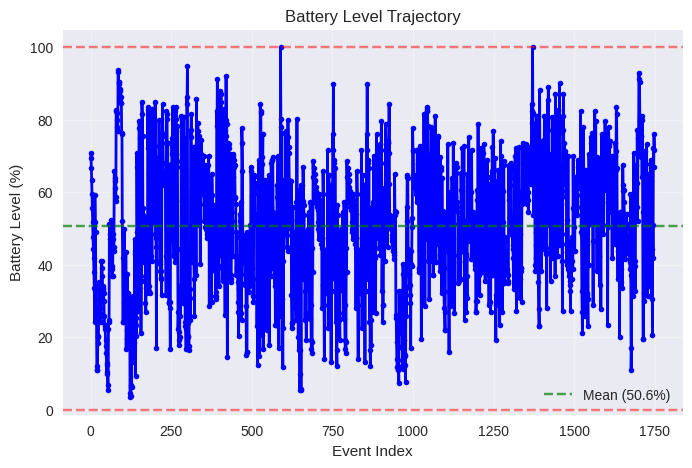

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV into DataFrame
df = pd.read_csv("./datasets/EV_data.csv")

# Extract the 'soc' column (state of charge)
trace = df['soc']

# Compute statistics
mean_soc = trace.mean()
median_soc = trace.median()
std_soc = trace.std()

print(f"Mean SOC: {mean_soc:.2f}%")
print(f"Median SOC: {median_soc:.2f}%")
print(f"Standard Deviation SOC: {std_soc:.2f}%")

# Create figure and axes
fig, ax = plt.subplots(figsize=(8,5))

# Plot the SOC trajectory
ax.plot(trace, linewidth=2, marker='o', markersize=4, color='blue')

# Add reference lines
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5)
#ax.axhline(y=50, color='green', linestyle='--', alpha=0.5, label='Optimal')

# Add mean line
ax.axhline(y=mean_soc, color='green', linestyle='--', alpha=0.7, label=f'Mean ({mean_soc:.1f}%)')

# Labels and title
ax.set_ylabel("Battery Level (%)")
ax.set_xlabel("Event Index")
ax.set_title("Battery Level Trajectory")

# Legend and grid
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


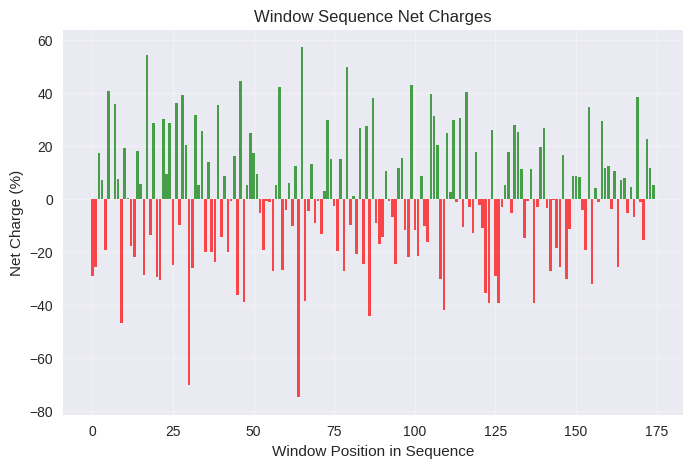

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("./datasets/EV_data.csv")

# Parameters
seq_len = 10
soc = df['soc'].tolist()

# Compute net charge per window
window_charges = []
for i in range(0, len(soc), seq_len):
    start_soc = soc[i]
    end_soc = soc[min(i + seq_len - 1, len(soc) - 1)]
    net_charge = end_soc - start_soc
    window_charges.append(net_charge)

# Assign colors: green for charge, red for discharge, gray for no change
colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in window_charges]

# Create single plot
plt.figure(figsize=(8,5))
plt.bar(range(len(window_charges)), window_charges, color=colors, alpha=0.7)
plt.xlabel('Window Position in Sequence')
plt.ylabel('Net Charge (%)')
plt.title(f'Window Sequence Net Charges')
plt.grid(True, alpha=0.3)

plt.show()


Mean SOC: 50.64%
Median SOC: 51.30%
Standard Deviation SOC: 18.09%


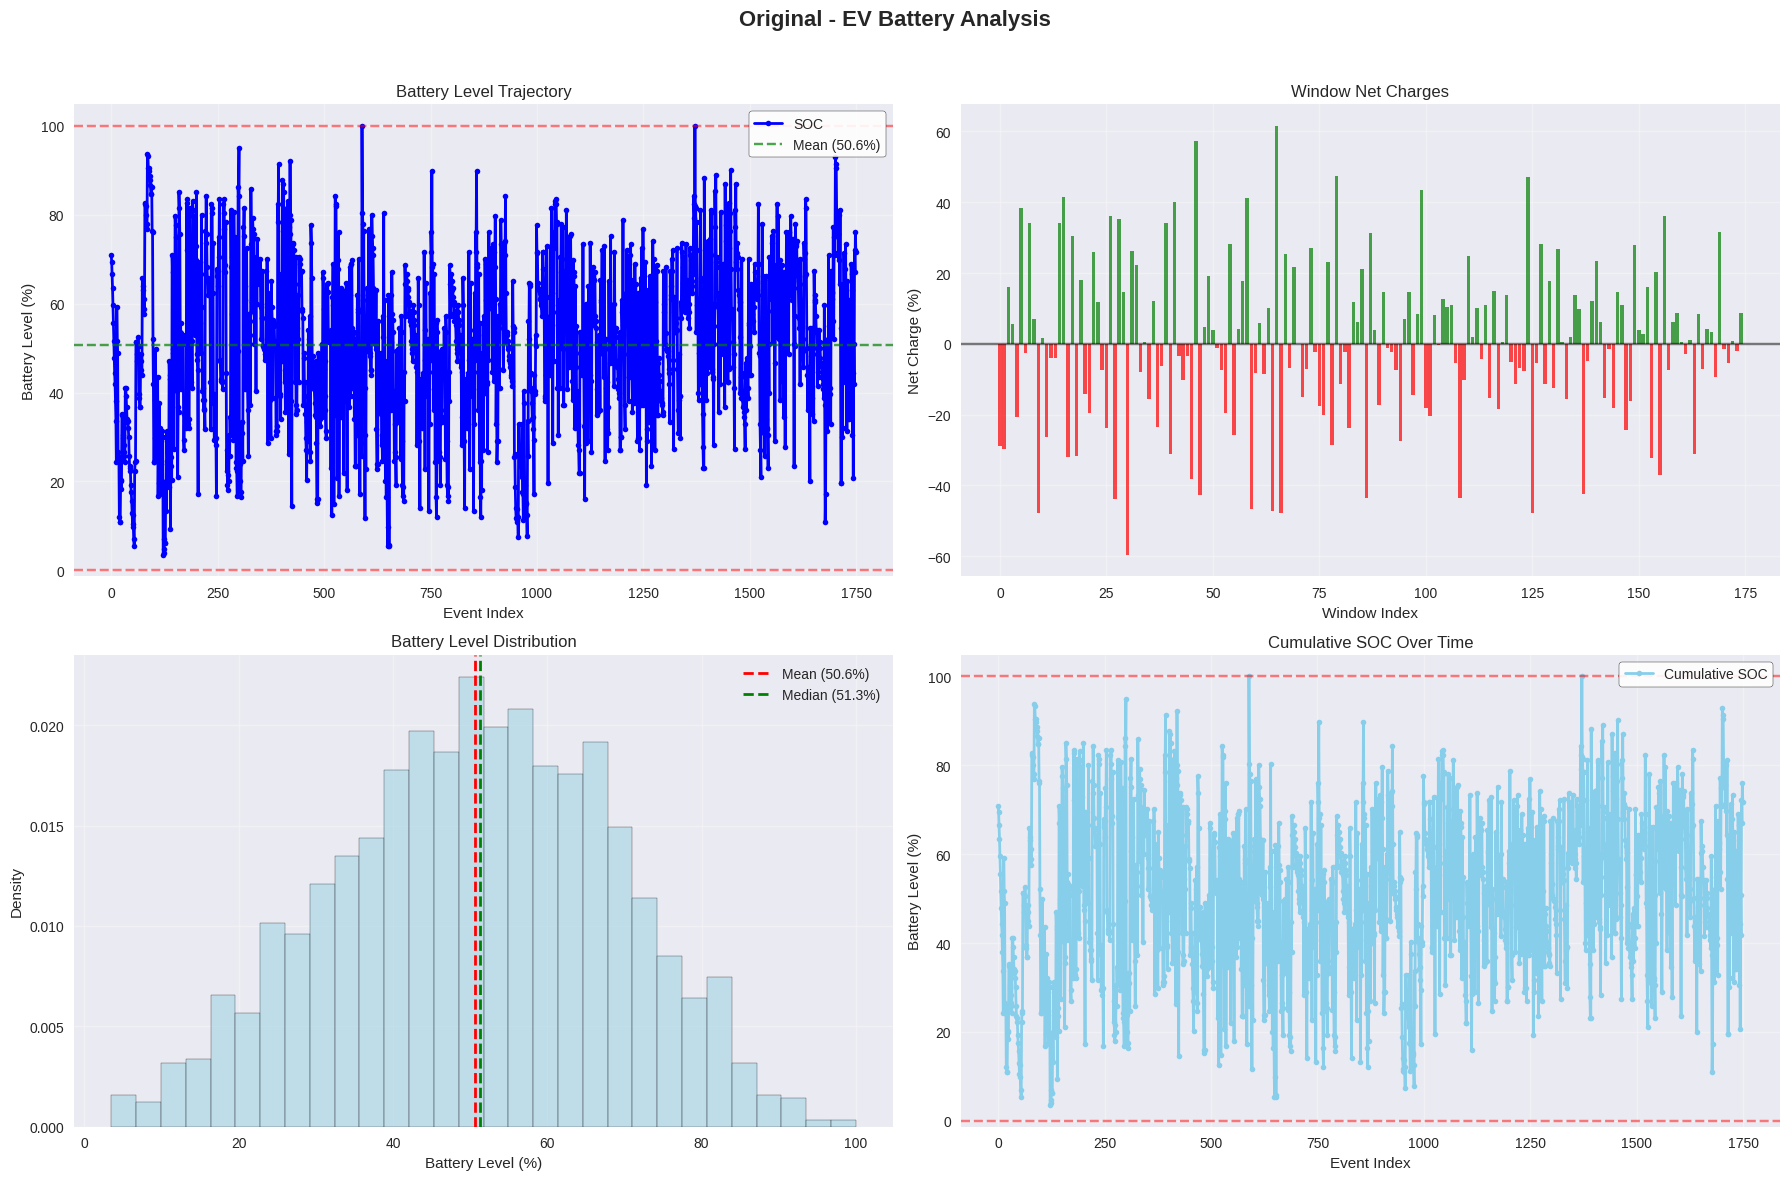

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV into DataFrame
df = pd.read_csv("./datasets/EV_data.csv")

# Extract the 'soc' column (state of charge)
trace = df['soc']

# Compute statistics
mean_soc = trace.mean()
median_soc = trace.median()
std_soc = trace.std()

print(f"Mean SOC: {mean_soc:.2f}%")
print(f"Median SOC: {median_soc:.2f}%")
print(f"Standard Deviation SOC: {std_soc:.2f}%")

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Original - EV Battery Analysis", fontsize=16, fontweight='bold')

# 1. Battery Level Trajectory
axes[0,0].plot(trace, linewidth=2, marker='o', markersize=4, color='blue', label='SOC')
axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0,0].axhline(y=100, color='red', linestyle='--', alpha=0.5)
axes[0,0].axhline(y=mean_soc, color='green', linestyle='--', alpha=0.7, label=f'Mean ({mean_soc:.1f}%)')
axes[0,0].set_xlabel("Event Index")
axes[0,0].set_ylabel("Battery Level (%)")
axes[0,0].set_title("Battery Level Trajectory")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='black')

# 2. Delta SOC between events
seq_len = 10

# Compute delta SOC
delta_soc = trace.diff().fillna(0)

# Split delta_soc into windows of length seq_len
n_windows = int(np.ceil(len(delta_soc) / seq_len))
window_sums = [delta_soc.iloc[i*seq_len : min((i+1)*seq_len, len(delta_soc))].sum() for i in range(n_windows)]

# Assign colors per window
colors_window = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in window_sums]

# Plot per window
axes[0,1].bar(range(len(window_sums)), window_sums, color=colors_window, alpha=0.7)
axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[0,1].set_xlabel("Window Index")
axes[0,1].set_ylabel("Net Charge (%)")
axes[0,1].set_title(f"Window Net Charges")
axes[0,1].grid(True, alpha=0.3)

# 3. Histogram of SOC values
axes[1,0].hist(trace, bins=30, alpha=0.7, color='lightblue', edgecolor='black', density=True)
axes[1,0].axvline(mean_soc, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_soc:.1f}%)')
axes[1,0].axvline(median_soc, color='green', linestyle='--', linewidth=2, label=f'Median ({median_soc:.1f}%)')
axes[1,0].set_xlabel("Battery Level (%)")
axes[1,0].set_ylabel("Density")
axes[1,0].set_title("Battery Level Distribution")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# 4. Cumulative SOC over time
cumulative_soc = delta_soc.cumsum() + trace.iloc[0]
axes[1,1].plot(cumulative_soc, linewidth=2, marker='o', markersize=4, color='skyblue', label='Cumulative SOC')
axes[1,1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1,1].axhline(y=100, color='red', linestyle='--', alpha=0.5)
axes[1,1].set_xlabel("Event Index")
axes[1,1].set_ylabel("Battery Level (%)")
axes[1,1].set_title("Cumulative SOC Over Time")
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='black')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.show()


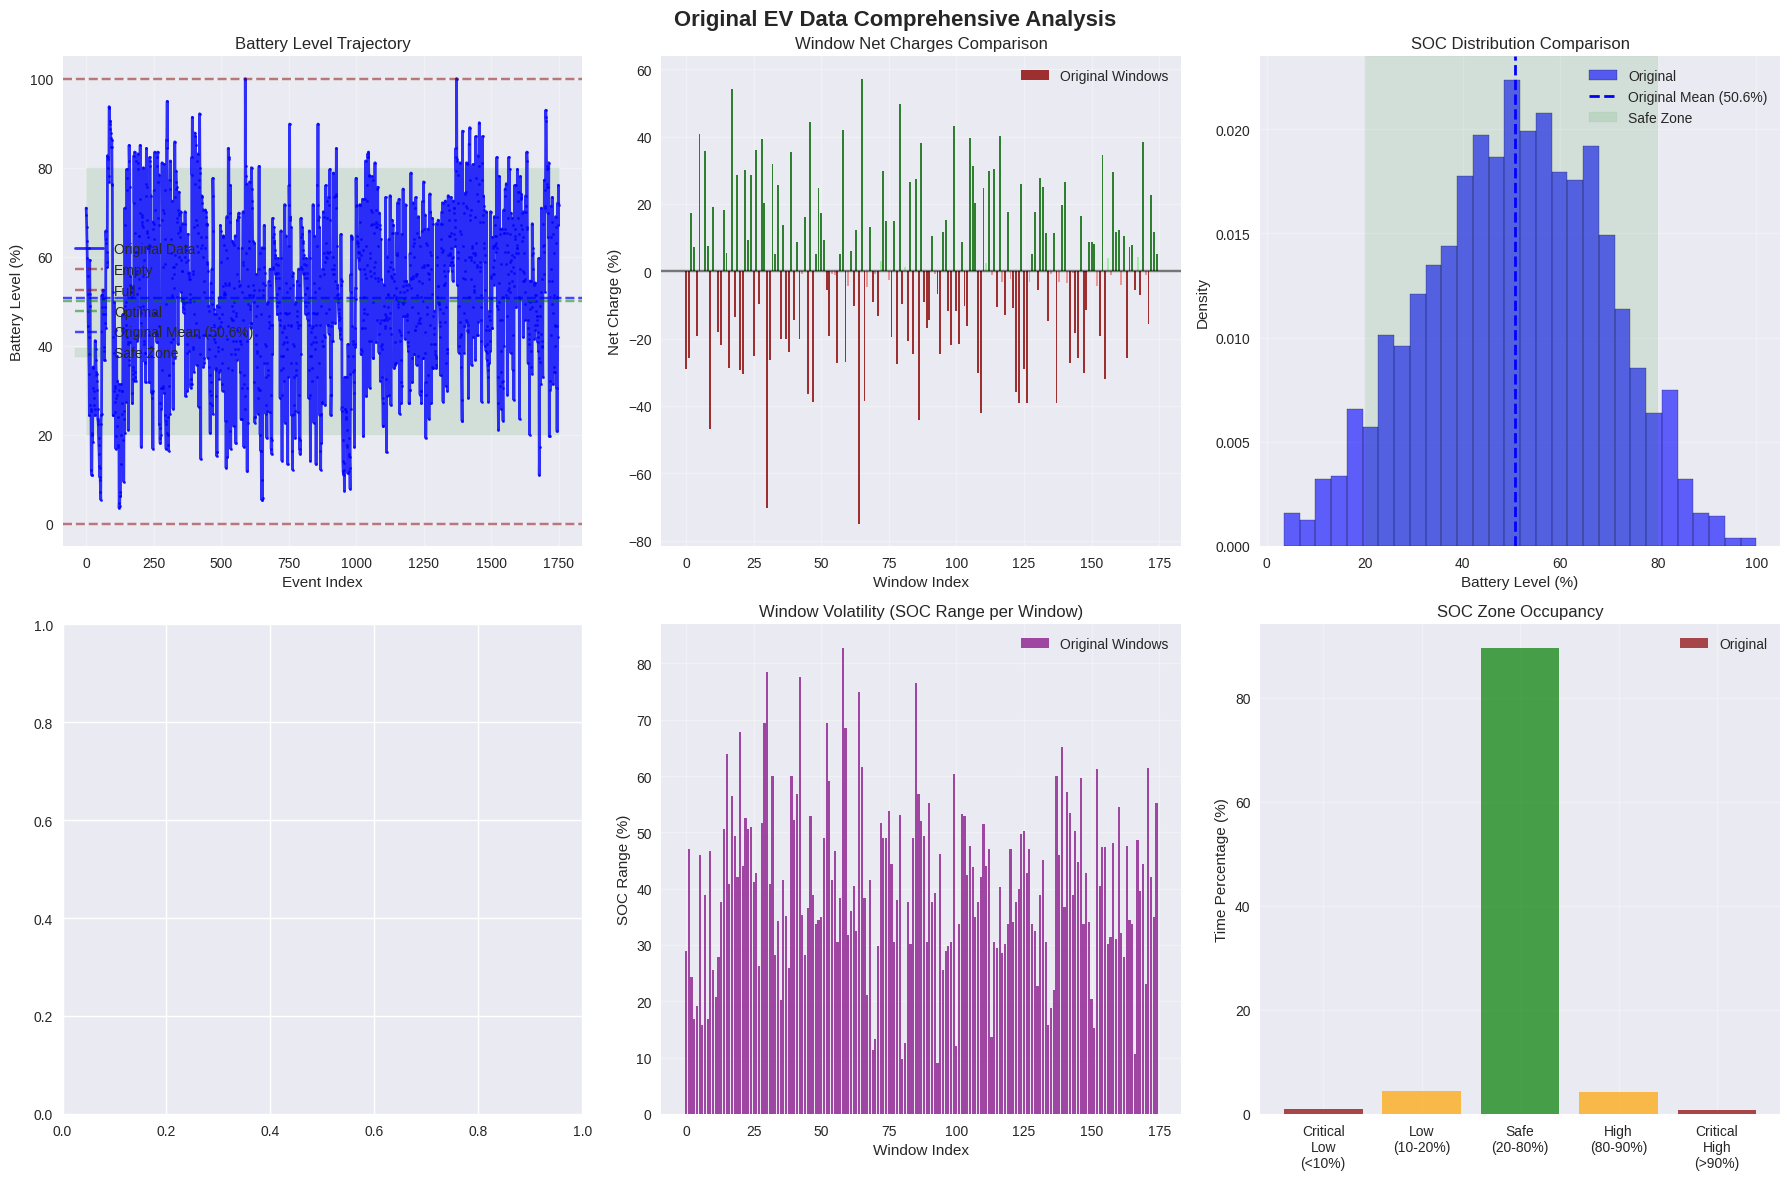

ORIGINAL DATA ANALYSIS
Total events: 1750
Total windows: 175
Window size: 10

SOC Statistics:
  Mean: 50.64%
  Median: 51.30%
  Std Dev: 18.09%
  Range: 3.5% - 100.0%

Zone Occupancy:
  Critical Low (<10%): 0.9%
  Low (10-20%): 4.5%
  Safe (20-80%): 89.7%
  High (80-90%): 4.2%
  Critical High (>90%): 0.7%

Window Analysis:
  Average window net charge: 0.21%
  Window charge std: 24.07%
  Average window volatility: 40.68%


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from typing import Optional, Dict, List

def visualize_original_data(csv_path: str, seq_len: int = 10, 
                          figsize: tuple = (20, 15),
                          ga_result: Optional[Dict] = None):
    """
    Enhanced visualization of original EV data with optional GA comparison
    
    Parameters:
    csv_path: Path to the original CSV file
    seq_len: Window size used for analysis
    figsize: Figure size
    ga_result: Optional result from GA reconstruction for comparison
    """
    
    # Load original data
    df = pd.read_csv(csv_path)
    
    # Check if required columns exist
    required_cols = ['soc']
    if 'charge' in df.columns:
        required_cols.append('charge')
    
    for col in required_cols:
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in data")
            return
    
    # Extract data
    soc_trace = df['soc'].tolist()
    charge_trace = df['charge'].tolist() if 'charge' in df.columns else None
    
    # Compute statistics
    mean_soc = np.mean(soc_trace)
    median_soc = np.median(soc_trace)
    std_soc = np.std(soc_trace, ddof=1)
    min_soc = min(soc_trace)
    max_soc = max(soc_trace)
    
    # Compute window-based statistics
    window_charges = []
    window_start_socs = []
    window_end_socs = []
    window_ranges = []
    
    for i in range(0, len(soc_trace), seq_len):
        window_socs = soc_trace[i:min(i + seq_len, len(soc_trace))]
        start_soc = window_socs[0]
        end_soc = window_socs[-1]
        net_charge = end_soc - start_soc
        window_range = max(window_socs) - min(window_socs)
        
        window_charges.append(net_charge)
        window_start_socs.append(start_soc)
        window_end_socs.append(end_soc)
        window_ranges.append(window_range)
    
    # Create comprehensive figure
    if ga_result is not None:
        fig, axes = plt.subplots(3, 3, figsize=figsize)
        fig.suptitle('Original Data vs Genetic Algorithm Reconstruction Comparison', 
                    fontsize=16, fontweight='bold')
    else:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Original EV Data Comprehensive Analysis', 
                    fontsize=16, fontweight='bold')
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten() if ga_result is not None else axes.flatten()
    
    # 1. SOC Trajectory Comparison
    axes_flat[0].plot(soc_trace, linewidth=2, marker='o', markersize=2, 
                     color='blue', alpha=0.8, label='Original Data')
    
    if ga_result is not None and ga_result['best_solution'] is not None:
        ga_trace = ga_result['best_solution']['trace']
        axes_flat[0].plot(ga_trace, linewidth=2, marker='s', markersize=2, 
                         color='red', alpha=0.8, label='GA Reconstruction')
    
    # Reference lines
    axes_flat[0].axhline(y=0, color='darkred', linestyle='--', alpha=0.5, label='Empty')
    axes_flat[0].axhline(y=100, color='darkred', linestyle='--', alpha=0.5, label='Full')
    axes_flat[0].axhline(y=50, color='green', linestyle='--', alpha=0.5, label='Optimal')
    axes_flat[0].axhline(y=mean_soc, color='blue', linestyle='--', alpha=0.7, 
                        label=f'Original Mean ({mean_soc:.1f}%)')
    axes_flat[0].fill_between(range(len(soc_trace)), 20, 80, alpha=0.1, color='green', label='Safe Zone')
    
    axes_flat[0].set_ylabel('Battery Level (%)')
    axes_flat[0].set_xlabel('Event Index')
    axes_flat[0].set_title('Battery Level Trajectory')
    axes_flat[0].legend()
    axes_flat[0].grid(True, alpha=0.3)
    
    # 2. Window Net Charges Comparison
    colors_orig = ['darkgreen' if x > 5 else 'lightgreen' if x > 0 else 'lightcoral' if x > -5 else 'darkred' 
                  for x in window_charges]
    
    width = 0.35 if ga_result is not None else 0.7
    x_pos = np.arange(len(window_charges))
    
    bars1 = axes_flat[1].bar(x_pos - width/2 if ga_result is not None else x_pos, 
                            window_charges, width, color=colors_orig, alpha=0.8, 
                            label='Original Windows')
    
    if ga_result is not None and ga_result['best_solution'] is not None:
        ga_sequence = ga_result['best_solution']['sequence']
        # Reconstruct window charges based on GA sequence
        ga_window_charges = []
        ga_soc = ga_result['start_battery']
        
        for window_id in ga_sequence:
            window_start = ga_soc
            # Simulate window execution (simplified)
            window_net = sum(df.iloc[window_id*seq_len:(window_id+1)*seq_len]['charge']) if 'charge' in df.columns else 0
            ga_window_charges.append(window_net)
        
        colors_ga = ['darkgreen' if x > 5 else 'lightgreen' if x > 0 else 'lightcoral' if x > -5 else 'darkred' 
                    for x in ga_window_charges]
        
        bars2 = axes_flat[1].bar(x_pos + width/2, ga_window_charges[:len(window_charges)], width, 
                               color=colors_ga, alpha=0.8, label='GA Reconstruction')
    
    axes_flat[1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    axes_flat[1].set_xlabel('Window Index')
    axes_flat[1].set_ylabel('Net Charge (%)')
    axes_flat[1].set_title('Window Net Charges Comparison')
    axes_flat[1].legend()
    axes_flat[1].grid(True, alpha=0.3)
    
    # 3. SOC Distribution Comparison
    axes_flat[2].hist(soc_trace, bins=30, alpha=0.6, color='blue', density=True, 
                     label='Original', edgecolor='black')
    
    if ga_result is not None and ga_result['best_solution'] is not None:
        ga_trace = ga_result['best_solution']['trace']
        axes_flat[2].hist(ga_trace, bins=30, alpha=0.6, color='red', density=True, 
                         label='GA Reconstruction', edgecolor='black')
    
    axes_flat[2].axvline(mean_soc, color='blue', linestyle='--', linewidth=2, 
                        label=f'Original Mean ({mean_soc:.1f}%)')
    axes_flat[2].axvspan(20, 80, alpha=0.1, color='green', label='Safe Zone')
    axes_flat[2].set_xlabel('Battery Level (%)')
    axes_flat[2].set_ylabel('Density')
    axes_flat[2].set_title('SOC Distribution Comparison')
    axes_flat[2].legend()
    axes_flat[2].grid(True, alpha=0.3)
    
    # 4. Charge Pattern Analysis (if charge data available)
    if charge_trace is not None:
        # Moving average of charge
        window_size = 50
        charge_ma = np.convolve(charge_trace, np.ones(window_size)/window_size, mode='valid')
        
        axes_flat[3].plot(charge_trace, alpha=0.3, color='gray', label='Raw Charge')
        axes_flat[3].plot(range(window_size-1, len(charge_trace)), charge_ma, 
                         color='orange', linewidth=2, label=f'Moving Average ({window_size})')
        axes_flat[3].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes_flat[3].set_xlabel('Event Index')
        axes_flat[3].set_ylabel('Charge Rate (%)')
        axes_flat[3].set_title('Charge Pattern Analysis')
        axes_flat[3].legend()
        axes_flat[3].grid(True, alpha=0.3)
    
    # 5. Window Volatility Analysis
    window_volatilities_orig = window_ranges
    
    axes_flat[4].bar(range(len(window_volatilities_orig)), window_volatilities_orig, 
                    alpha=0.7, color='purple', label='Original Windows')
    axes_flat[4].set_xlabel('Window Index')
    axes_flat[4].set_ylabel('SOC Range (%)')
    axes_flat[4].set_title('Window Volatility (SOC Range per Window)')
    axes_flat[4].legend()
    axes_flat[4].grid(True, alpha=0.3)
    
    # 6. Safety Analysis
    # Calculate time in different SOC zones
    critical_low = sum(1 for soc in soc_trace if soc < 10)
    low_zone = sum(1 for soc in soc_trace if 10 <= soc < 20)
    safe_zone = sum(1 for soc in soc_trace if 20 <= soc <= 80)
    high_zone = sum(1 for soc in soc_trace if 80 < soc <= 90)
    critical_high = sum(1 for soc in soc_trace if soc > 90)
    
    zones = ['Critical\nLow\n(<10%)', 'Low\n(10-20%)', 'Safe\n(20-80%)', 'High\n(80-90%)', 'Critical\nHigh\n(>90%)']
    counts_orig = [critical_low, low_zone, safe_zone, high_zone, critical_high]
    percentages_orig = [c/len(soc_trace)*100 for c in counts_orig]
    
    colors_zones = ['darkred', 'orange', 'green', 'orange', 'darkred']
    bars = axes_flat[5].bar(zones, percentages_orig, color=colors_zones, alpha=0.7, label='Original')
    
    if ga_result is not None and ga_result['best_solution'] is not None:
        ga_trace = ga_result['best_solution']['trace']
        critical_low_ga = sum(1 for soc in ga_trace if soc < 10)
        low_zone_ga = sum(1 for soc in ga_trace if 10 <= soc < 20)
        safe_zone_ga = sum(1 for soc in ga_trace if 20 <= soc <= 80)
        high_zone_ga = sum(1 for soc in ga_trace if 80 < soc <= 90)
        critical_high_ga = sum(1 for soc in ga_trace if soc > 90)
        
        counts_ga = [critical_low_ga, low_zone_ga, safe_zone_ga, high_zone_ga, critical_high_ga]
        percentages_ga = [c/len(ga_trace)*100 for c in counts_ga]
        
        x_pos = np.arange(len(zones))
        width = 0.35
        axes_flat[5].clear()  # Clear and redraw with side-by-side bars
        axes_flat[5].bar(x_pos - width/2, percentages_orig, width, color=colors_zones, 
                        alpha=0.7, label='Original')
        axes_flat[5].bar(x_pos + width/2, percentages_ga, width, color=colors_zones, 
                        alpha=0.7, label='GA Reconstruction', hatch='///')
        axes_flat[5].set_xticks(x_pos)
        axes_flat[5].set_xticklabels(zones)
    
    axes_flat[5].set_ylabel('Time Percentage (%)')
    axes_flat[5].set_title('SOC Zone Occupancy')
    axes_flat[5].legend()
    axes_flat[5].grid(True, alpha=0.3)
    
    # Add additional plots if GA result is available
    if ga_result is not None:
        # 7. Fitness Evolution (if available)
        axes_flat[6].text(0.5, 0.5, 'Fitness Evolution\n(Not implemented in current GA)', 
                         ha='center', va='center', transform=axes_flat[6].transAxes, 
                         fontsize=12)
        axes_flat[6].set_title('Algorithm Performance')
        
        # 8. Sequence Order Analysis
        if ga_result['best_solution'] is not None:
            ga_sequence = ga_result['best_solution']['sequence']
            natural_order = list(range(len(ga_sequence)))
            
            axes_flat[7].plot(natural_order, 'o-', label='Natural Order', color='blue')
            axes_flat[7].plot(ga_sequence, 's-', label='GA Sequence', color='red', alpha=0.7)
            axes_flat[7].set_xlabel('Position')
            axes_flat[7].set_ylabel('Window ID')
            axes_flat[7].set_title('Window Sequence Order')
            axes_flat[7].legend()
            axes_flat[7].grid(True, alpha=0.3)
        
        # 9. Statistical Comparison Table
        axes_flat[8].axis('off')
        
        # Create comparison table
        stats_orig = {
            'Mean SOC': f"{mean_soc:.2f}%",
            'Std SOC': f"{std_soc:.2f}%",
            'Min SOC': f"{min_soc:.1f}%",
            'Max SOC': f"{max_soc:.1f}%",
            'Range': f"{max_soc - min_soc:.1f}%",
            'Safe Zone %': f"{safe_zone/len(soc_trace)*100:.1f}%"
        }
        
        if ga_result['best_solution'] is not None:
            ga_trace = ga_result['best_solution']['trace']
            ga_safe = sum(1 for soc in ga_trace if 20 <= soc <= 80)
            stats_ga = {
                'Mean SOC': f"{np.mean(ga_trace):.2f}%",
                'Std SOC': f"{np.std(ga_trace, ddof=1):.2f}%",
                'Min SOC': f"{min(ga_trace):.1f}%",
                'Max SOC': f"{max(ga_trace):.1f}%",
                'Range': f"{max(ga_trace) - min(ga_trace):.1f}%",
                'Safe Zone %': f"{ga_safe/len(ga_trace)*100:.1f}%"
            }
            
            table_data = []
            for key in stats_orig.keys():
                table_data.append([key, stats_orig[key], stats_ga[key]])
            
            table = axes_flat[8].table(cellText=table_data, 
                                     colLabels=['Metric', 'Original', 'GA Reconstruction'],
                                     cellLoc='center', loc='center')
            table.auto_set_font_size(False)
            table.set_fontsize(10)
            table.scale(1, 2)
            axes_flat[8].set_title('Statistical Comparison', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("="*60)
    print("ORIGINAL DATA ANALYSIS")
    print("="*60)
    print(f"Total events: {len(soc_trace)}")
    print(f"Total windows: {len(window_charges)}")
    print(f"Window size: {seq_len}")
    print()
    print("SOC Statistics:")
    print(f"  Mean: {mean_soc:.2f}%")
    print(f"  Median: {median_soc:.2f}%")
    print(f"  Std Dev: {std_soc:.2f}%")
    print(f"  Range: {min_soc:.1f}% - {max_soc:.1f}%")
    print()
    print("Zone Occupancy:")
    print(f"  Critical Low (<10%): {critical_low/len(soc_trace)*100:.1f}%")
    print(f"  Low (10-20%): {low_zone/len(soc_trace)*100:.1f}%")
    print(f"  Safe (20-80%): {safe_zone/len(soc_trace)*100:.1f}%")
    print(f"  High (80-90%): {high_zone/len(soc_trace)*100:.1f}%")
    print(f"  Critical High (>90%): {critical_high/len(soc_trace)*100:.1f}%")
    print()
    print("Window Analysis:")
    print(f"  Average window net charge: {np.mean(window_charges):.2f}%")
    print(f"  Window charge std: {np.std(window_charges, ddof=1):.2f}%")
    print(f"  Average window volatility: {np.mean(window_ranges):.2f}%")


# Example usage
if __name__ == "__main__":
    # Visualize original data only
    visualize_original_data("./datasets/EV_data.csv", seq_len=10)
    
    # Or with GA comparison (after running reconstruction)
    # result = reconstructor.reconstruct_timeline(start_battery=50.0)
    # visualize_original_data("EV_data.csv", seq_len=10, ga_result=result)

In [19]:
import json

with open("timeline_reconstruction.json", "w") as f:
    json.dump(result, f)


Loaded original dataset: 175 windows of length 10
Loaded generated dataset: 1609 windows of length 10
🔋 EV DATASET COMPARISON ANALYSIS REPORT
DATASET COMPARISON - BASIC STATISTICS

ORIGINAL DATASET:
----------------------------------------
Total events: 1750
Number of windows: 175
duration_minutes: μ=106.08, σ=182.77, range=[0.00, 1974.00]
km_driven: μ=28.28, σ=43.13, range=[0.00, 378.19]
charge: μ=-0.10, σ=15.87, range=[-74.60, 65.10]

GENERATED DATASET:
----------------------------------------
Total events: 16090
Number of windows: 1609
duration_minutes: μ=97.36, σ=125.93, range=[13.32, 1119.74]
km_driven: μ=32.20, σ=47.56, range=[1.29, 229.06]
charge: μ=-2.58, σ=14.49, range=[-40.60, 37.89]
DATASET COMPARISON - CHARGING PATTERNS

ORIGINAL:
  Total charging: 9326.30%
  Total discharging: 9496.70%
  Net change: -170.40%
  Charge/Discharge ratio: 0.98

GENERATED:
  Total charging: 67001.41%
  Total discharging: 108446.63%
  Net change: -41445.22%
  Charge/Discharge ratio: 0.62
DATASET 

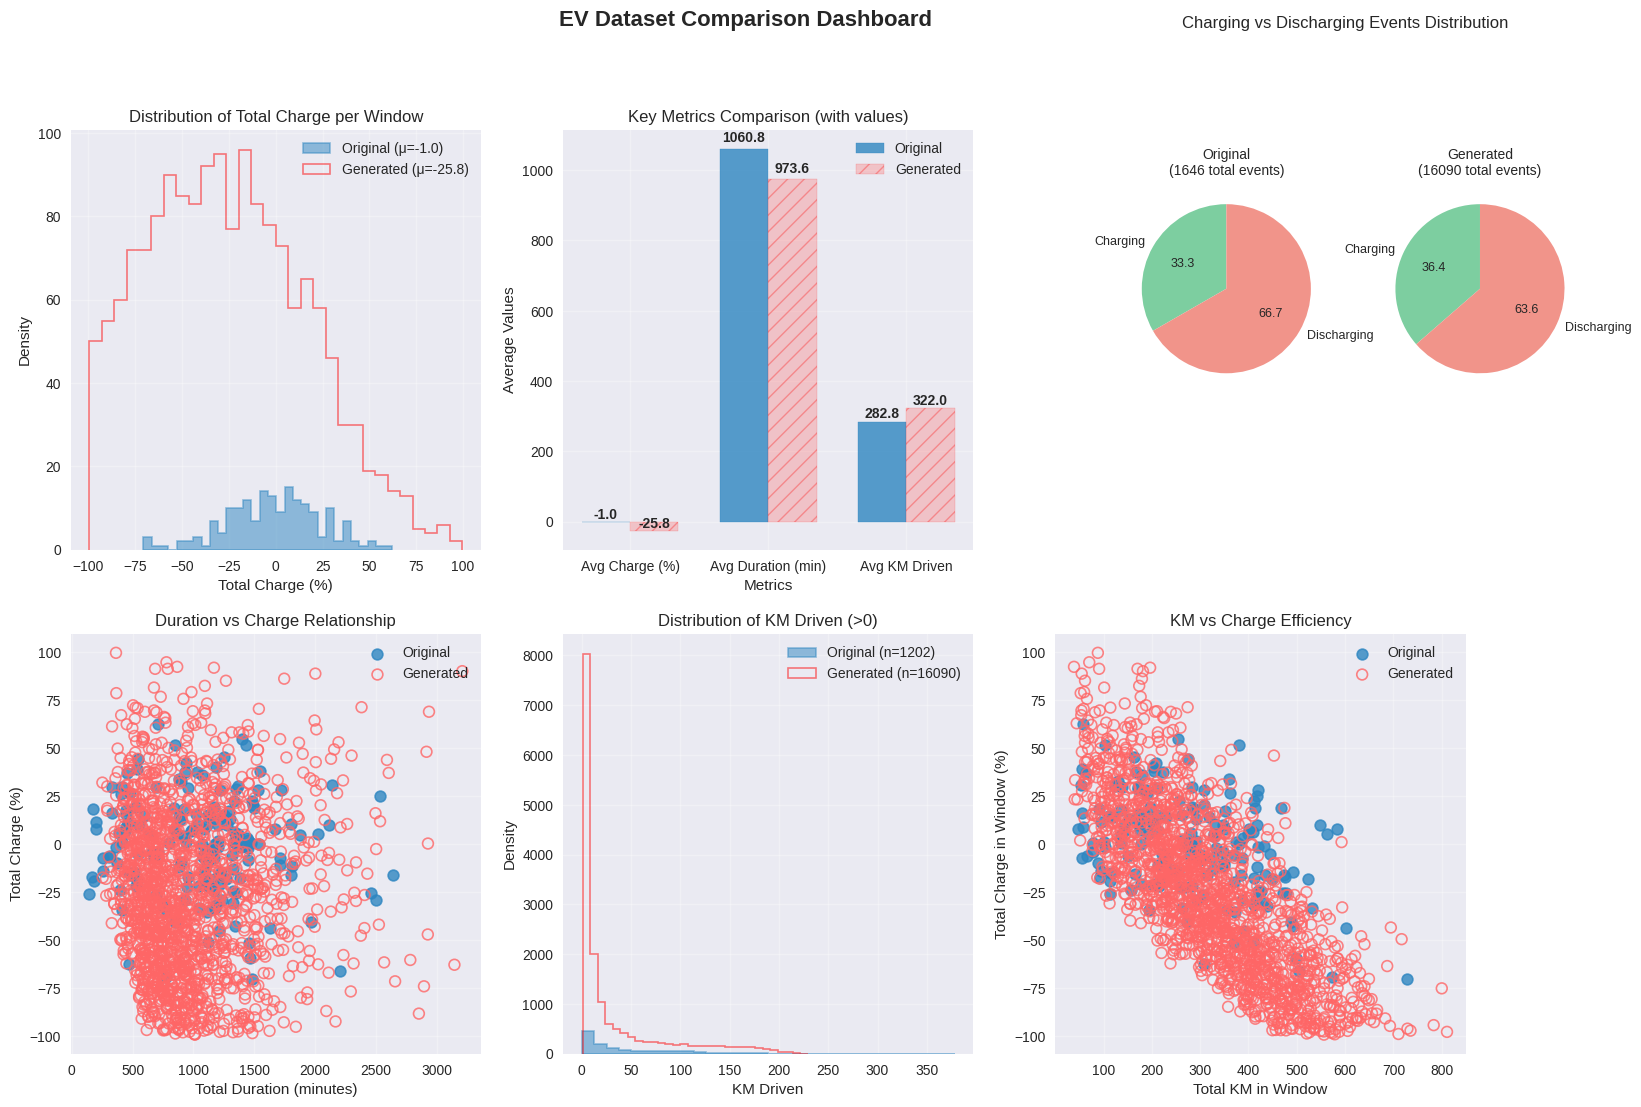

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class EVWindowComparator:
    """
    Comprehensive analyzer for comparing EV time series windows between datasets
    """
    
    def __init__(self, seq_len=10):
        """
        Initialize comparator
        
        Parameters:
        seq_len: int, sequence length of each window
        """
        self.seq_len = seq_len
        self.feature_names = ['event', 'charge_mode', 'duration_minutes', 'km_driven', 'charge']
        self.datasets = {}
        self.window_stats = {}
        
    def load_dataset(self, name, data_path=None, df=None):
        """
        Load and process a dataset
        
        Parameters:
        name: str, name identifier for the dataset
        data_path: str, path to CSV file (optional if df provided)
        df: DataFrame, pre-loaded dataframe (optional if data_path provided)
        """
        if df is not None:
            processed_df = df.copy()
        elif data_path is not None:
            processed_df = pd.read_csv(data_path)
        else:
            raise ValueError("Either data_path or df must be provided")
        
        # Process based on dataset type
        if name == 'original':
            processed_df['charge'] = processed_df['end_soc'] - processed_df['soc']
            processed_df['km_driven'] = processed_df['end_odo'] - processed_df['odo']
            # Convert timestamps to datetime
            processed_df['timestamp'] = pd.to_datetime(processed_df['timestamp'], errors='coerce')
            processed_df['end_time'] = pd.to_datetime(processed_df['end_time'], errors='coerce')
            # Compute event duration in minutes
            processed_df['duration_minutes'] = (processed_df['end_time'] - processed_df['timestamp']).dt.total_seconds() / 60
        
        # Split into windows
        windows = [processed_df.iloc[i:i+self.seq_len] for i in range(0, len(processed_df), self.seq_len)]
        # Filter windows with reasonable charge sums
        windows = [w for w in windows if -100 <= w['charge'].sum() <= 100 and len(w) == self.seq_len]
        
        self.datasets[name] = {
            'data': processed_df,
            'windows': windows,
            'n_windows': len(windows)
        }
        
        print(f"Loaded {name} dataset: {len(windows)} windows of length {self.seq_len}")
        
    def compute_window_statistics(self, name):
        """Compute statistics for windows of a dataset"""
        windows = self.datasets[name]['windows']
        window_stats = []
        
        for i, window in enumerate(windows):
            stats_dict = {
                'window_id': i,
                'dataset': name,
                'total_charge': window['charge'].sum(),
                'net_charge': window['charge'].sum(),
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'n_charging_events': (window['charge'] > 0).sum(),
                'n_discharging_events': (window['charge'] < 0).sum(),
                'max_single_charge': window['charge'].max(),
                'min_single_charge': window['charge'].min(),
                'charging_efficiency': window[window['charge'] > 0]['charge'].sum() if (window['charge'] > 0).any() else 0,
                'discharging_total': abs(window[window['charge'] < 0]['charge'].sum()) if (window['charge'] < 0).any() else 0,
                'avg_event_duration': window['duration_minutes'].mean(),
                'longest_event': window['duration_minutes'].max(),
                'shortest_event': window['duration_minutes'].min()
            }
            
            # Event type analysis (if categorical)
            if 'event' in window.columns:
                event_counts = window['event'].value_counts()
                for event_type in event_counts.index:
                    stats_dict[f'n_{event_type}_events'] = event_counts[event_type]
            
            # Charge mode analysis (if categorical)
            if 'charge_mode' in window.columns:
                mode_counts = window['charge_mode'].value_counts()
                stats_dict['most_common_charge_mode'] = mode_counts.index[0] if len(mode_counts) > 0 else 'N/A'
                stats_dict['n_unique_charge_modes'] = len(mode_counts)
            
            window_stats.append(stats_dict)
        
        self.window_stats[name] = pd.DataFrame(window_stats)
        return self.window_stats[name]
    
    def basic_comparison(self):
        """Compare basic statistics between datasets"""
        print("="*80)
        print("DATASET COMPARISON - BASIC STATISTICS")
        print("="*80)
        
        for name in self.datasets.keys():
            print(f"\n{name.upper()} DATASET:")
            print("-" * 40)
            
            # Aggregate all windows
            all_data = pd.concat(self.datasets[name]['windows'], ignore_index=True)
            
            print(f"Total events: {len(all_data)}")
            print(f"Number of windows: {self.datasets[name]['n_windows']}")
            
            # Feature statistics
            for col in ['duration_minutes', 'km_driven', 'charge']:
                if col in all_data.columns:
                    print(f"{col}: μ={all_data[col].mean():.2f}, σ={all_data[col].std():.2f}, "
                          f"range=[{all_data[col].min():.2f}, {all_data[col].max():.2f}]")
    
    def charge_comparison(self):
        """Compare charging patterns between datasets"""
        print("="*80)
        print("DATASET COMPARISON - CHARGING PATTERNS")
        print("="*80)
        
        comparison_results = {}
        
        for name in self.datasets.keys():
            windows = self.datasets[name]['windows']
            
            total_charging = sum(window[window['charge'] > 0]['charge'].sum() for window in windows)
            total_discharging = sum(abs(window[window['charge'] < 0]['charge'].sum()) for window in windows)
            
            comparison_results[name] = {
                'total_charging': total_charging,
                'total_discharging': total_discharging,
                'net_change': total_charging - total_discharging,
                'charge_discharge_ratio': total_charging/total_discharging if total_discharging > 0 else float('inf')
            }
            
            print(f"\n{name.upper()}:")
            print(f"  Total charging: {total_charging:.2f}%")
            print(f"  Total discharging: {total_discharging:.2f}%")
            print(f"  Net change: {total_charging - total_discharging:.2f}%")
            print(f"  Charge/Discharge ratio: {comparison_results[name]['charge_discharge_ratio']:.2f}")
        
        return comparison_results
    
    def event_comparison(self):
        """Compare event types between datasets"""
        print("="*80)
        print("DATASET COMPARISON - EVENT ANALYSIS")
        print("="*80)
        
        for name in self.datasets.keys():
            print(f"\n{name.upper()} EVENT DISTRIBUTION:")
            all_events = pd.concat(self.datasets[name]['windows'], ignore_index=True)
            
            if 'event' in all_events.columns:
                event_dist = all_events['event'].value_counts(normalize=True) * 100
                for event_type, pct in event_dist.items():
                    print(f"  {event_type}: {pct:.1f}%")
            
            if 'charge_mode' in all_events.columns:
                mode_dist = all_events['charge_mode'].value_counts(normalize=True) * 100
                print("  Charge modes:")
                for mode, pct in mode_dist.items():
                    print(f"    {mode}: {pct:.1f}%")
    
    def visualize_comparison(self, figsize=(18, 12)):
        """Create comprehensive comparison visualizations with clearer styles and fixed point sizes"""
        combined_stats = pd.concat([stats.assign(dataset=name) for name, stats in self.window_stats.items()])
    
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('EV Dataset Comparison Dashboard', fontsize=16, fontweight='bold')
    
        # High-contrast colors: Blue (original) vs Light Pink (generated)
        style_map = {
            'original': {'color': '#2E86C1', 'edge_color': '#2E86C1', 'fill': True, 'marker': 'o'},
            'generated': {'color': '#FF6666', 'edge_color': '#FF0000', 'fill': False, 'marker': 'o'}
        }
        dataset_names = list(self.datasets.keys())
        fixed_size = 60  # fixed size for all scatter points
    
        # 1. Window charge distribution
        for name in dataset_names:
            data = self.window_stats[name]['total_charge']
            style = style_map[name]
    
            axes[0,0].hist(data, bins=30, alpha=0.5,
                           label=f'{name.title()} (μ={data.mean():.1f})',
                           color=style['color'],
                           edgecolor=style['edge_color'],
                           linewidth=1.2,
                           histtype='stepfilled' if style['fill'] else 'step')
        axes[0,0].set_title('Distribution of Total Charge per Window')
        axes[0,0].set_xlabel('Total Charge (%)')
        axes[0,0].set_ylabel('Density')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
    
        # 2. Key metrics bar comparison
        metrics = ['total_charge', 'total_duration', 'total_km']
        metric_labels = ['Avg Charge (%)', 'Avg Duration (min)', 'Avg KM Driven']
    
        comparison_data = {name: [
            self.window_stats[name]['total_charge'].mean(),
            self.window_stats[name]['total_duration'].mean(),
            self.window_stats[name]['total_km'].mean()
        ] for name in dataset_names}
    
        x = np.arange(len(metrics))
        width = 0.35
    
        for i, name in enumerate(dataset_names):
            values = comparison_data[name]
            style = style_map[name]
    
            bars = axes[0,1].bar(x + i*width, values, width,
                                 label=f'{name.title()}',
                                 color=style['color'],
                                 alpha=0.8 if style['fill'] else 0.3,
                                 edgecolor=style['edge_color'],
                                 hatch='//' if not style['fill'] else None)
    
            for bar, value in zip(bars, values):
                height = bar.get_height()
                axes[0,1].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                               f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
    
        axes[0,1].set_xlabel('Metrics')
        axes[0,1].set_ylabel('Average Values')
        axes[0,1].set_title('Key Metrics Comparison (with values)')
        axes[0,1].set_xticks(x + width/2)
        axes[0,1].set_xticklabels(metric_labels)
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
    
        # 3. Charging vs Discharging events
        if len(dataset_names) == 2:
            gs = axes[0,2].get_gridspec()
            axes[0,2].remove()
            subfigs = fig.add_subfigure(gs[0, 2])
            sub_axes = subfigs.subplots(1, 2)
    
            for i, name in enumerate(dataset_names):
                charge_pos = self.window_stats[name]['n_charging_events'].sum()
                charge_neg = self.window_stats[name]['n_discharging_events'].sum()
                total = charge_pos + charge_neg
    
                labels = ['Charging', 'Discharging']
                colors_pie = ['#7DCEA0', '#F1948A']
    
                sub_axes[i].pie([charge_pos, charge_neg], labels=labels, colors=colors_pie, autopct='%1.1f',
                                startangle=90, textprops={'fontsize': 9})
                sub_axes[i].set_title(f'{name.title()}\n({total} total events)', fontsize=10)
    
            subfigs.suptitle('Charging vs Discharging Events Distribution', fontsize=12, y=0.95)
    
        # 4. Duration vs Charge scatter
        for name in dataset_names:
            data = self.window_stats[name]
            style = style_map[name]
    
            axes[1,0].scatter(data['total_duration'], data['total_charge'],
                              alpha=0.8,
                              label=f'{name.title()}',
                              facecolors=style['color'] if style['fill'] else 'none',
                              edgecolors=style['color'],
                              marker=style['marker'],
                              s=fixed_size,
                              linewidth=1.2)
        axes[1,0].set_xlabel('Total Duration (minutes)')
        axes[1,0].set_ylabel('Total Charge (%)')
        axes[1,0].set_title('Duration vs Charge Relationship')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
    
        # 5. KM driven distribution
        for name in dataset_names:
            all_data = pd.concat(self.datasets[name]['windows'])
            km_data = all_data['km_driven'][all_data['km_driven'] > 0]
            style = style_map[name]
    
            if len(km_data) > 0:
                axes[1,1].hist(km_data, bins=30,
                               label=f'{name.title()} (n={len(km_data)})',
                               color=style['edge_color'],
                               alpha=0.5,
                               edgecolor=style['edge_color'],
                               linewidth=1.2,
                               histtype='stepfilled' if style['fill'] else 'step')
        axes[1,1].set_xlabel('KM Driven')
        axes[1,1].set_ylabel('Density')
        axes[1,1].set_title('Distribution of KM Driven (>0)')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
    
        # 6. KM vs Charge scatter with fixed point size
        for name in dataset_names:
            data = self.window_stats[name]
            style = style_map[name]
    
            axes[1,2].scatter(data['total_km'], data['total_charge'],
                              alpha=0.8,
                              label=f'{name.title()}',
                              facecolors=style['color'] if style['fill'] else 'none',
                              edgecolors=style['color'],
                              marker=style['marker'],
                              s=fixed_size,
                              linewidth=1.2)
        axes[1,2].set_xlabel('Total KM in Window')
        axes[1,2].set_ylabel('Total Charge in Window (%)')
        axes[1,2].set_title('KM vs Charge Efficiency')
        axes[1,2].legend()
        axes[1,2].grid(True, alpha=0.3)
    
        plt.tight_layout()
        plt.show()


    
    def statistical_tests(self):
        """Perform statistical tests to compare datasets"""
        if len(self.datasets) < 2:
            print("Need at least 2 datasets for statistical comparison")
            return
        
        print("="*80)
        print("STATISTICAL COMPARISON TESTS")
        print("="*80)
        
        dataset_names = list(self.datasets.keys())
        
        # Compare key metrics between first two datasets
        name1, name2 = dataset_names[0], dataset_names[1]
        stats1, stats2 = self.window_stats[name1], self.window_stats[name2]
        
        metrics_to_compare = ['total_charge', 'total_duration', 'total_km']
        
        for metric in metrics_to_compare:
            if metric in stats1.columns and metric in stats2.columns:
                # Perform t-test
                stat, p_value = stats.ttest_ind(stats1[metric].dropna(), stats2[metric].dropna())
                
                # Perform Mann-Whitney U test (non-parametric)
                u_stat, u_p_value = stats.mannwhitneyu(stats1[metric].dropna(), stats2[metric].dropna())
                
                print(f"\n{metric.upper()}:")
                print(f"  {name1} mean: {stats1[metric].mean():.3f} ± {stats1[metric].std():.3f}")
                print(f"  {name2} mean: {stats2[metric].mean():.3f} ± {stats2[metric].std():.3f}")
                print(f"  T-test p-value: {p_value:.6f}")
                print(f"  Mann-Whitney U p-value: {u_p_value:.6f}")
                print(f"  Significantly different: {'Yes' if p_value < 0.05 else 'No'}")
    
    def data_quality_comparison(self):
        """Check data quality across datasets"""
        print("="*80)
        print("DATA QUALITY COMPARISON")
        print("="*80)
        
        for name in self.datasets.keys():
            print(f"\n{name.upper()} QUALITY CHECK:")
            windows = self.datasets[name]['windows']
            issues = []
            
            # Check for missing values
            for i, window in enumerate(windows):
                missing = window.isnull().sum()
                if missing.any():
                    issues.append(f"Window {i}: Missing values - {missing.to_dict()}")
            
            # Check for impossible values
            all_data = pd.concat(windows, ignore_index=True)
            
            if (all_data['charge'] > 100).any():
                issues.append("Found charge values > 100%")
            if (all_data['charge'] < -100).any():
                issues.append("Found charge values < -100%")
            if (all_data['duration_minutes'] < 0).any():
                issues.append("Found negative duration values")
            if (all_data['km_driven'] < 0).any():
                issues.append("Found negative km_driven values")
            
            if issues:
                print("  ISSUES FOUND:")
                for issue in issues:
                    print(f"  ⚠️  {issue}")
            else:
                print("  ✅ No data quality issues detected!")
    
    def generate_comparison_report(self):
        """Generate comprehensive comparison report"""
        print("🔋 EV DATASET COMPARISON ANALYSIS REPORT")
        print("="*80)
        
        # Compute statistics for all datasets
        for name in self.datasets.keys():
            self.compute_window_statistics(name)
        
        # Run all comparison analyses
        self.basic_comparison()
        charge_results = self.charge_comparison()
        self.event_comparison()
        self.statistical_tests()
        self.data_quality_comparison()
        
        # Generate comparison visualizations
        self.visualize_comparison()
        
        return {
            'window_stats': self.window_stats,
            'charge_comparison': charge_results,
            'datasets_info': {name: {'n_windows': info['n_windows']} 
                            for name, info in self.datasets.items()}
        }

# USAGE 
def main():
    # Initialize comparator
    comparator = EVWindowComparator(seq_len=10)
    
    # Load original dataset
    comparator.load_dataset('original', data_path='./datasets/EV_data.csv')
    
    # Load generated dataset
    comparator.load_dataset('generated', data_path='./Generated_data/EV_generated_data.csv')
    
    # Generate comparison report
    results = comparator.generate_comparison_report()
    
    return results


results = main()